# GLAAM-4X v4 — Unified Multi-Dataset Fundus Disease Detection (Google Colab)

This notebook trains **GLAAM-4X**, a multi-label deep learning classifier for detecting four sight-threatening diseases — Cataract, Diabetic Retinopathy (DR), Glaucoma, and Myopia — from a single retinal fundus photograph. The model is trained on a unified corpus of public datasets plus synthetic cataract images, and is designed to be lightweight enough for screening workflows while retaining clinical-grade discriminative performance.

The four diseases differ markedly in visual appearance and prevalence, making this a challenging multi-label, imbalanced-classification problem. The notebook addresses these challenges through disease-specific attention heads, asymmetric loss, balanced sampling, differential augmentation, and a carefully tuned learning-rate schedule. All training artifacts, including checkpoints, metrics, graphs, and an inference package, are saved to Google Drive so they persist beyond the Colab session.

To use the notebook, upload the project folder (containing `models/`, `utils/`, `raw/`, `synthetic/`, and the four CSV splits) to the Drive path set in `DRIVE_BASE`, then run the cells sequentially.

In [1]:
import subprocess
import sys
import importlib.metadata as md

if "numpy" in sys.modules:
    import numpy as _np_check
    _runtime_v = _np_check.__version__
    _meta_v = md.version("numpy")
    if _runtime_v != _meta_v:
        raise RuntimeError(
            f"Pre-loaded numpy is corrupted: runtime={_runtime_v} vs "
            f"installed metadata={_meta_v}. Restart the runtime and run this cell first."
        )
    print(f"Pre-loaded numpy {_runtime_v} looks consistent — proceeding.")
    del _np_check, _runtime_v, _meta_v

# albumentations removed from this list — it was the one package here whose
# numpy floor sits above what Modal preloads, which is what forced the
# force-reinstall-under-an-already-imported-numpy crash in the first place.
# Everything remaining (pandas/scipy/scikit-learn/opencv-headless) is fine
# with the numpy that's already loaded, so we don't need --force-reinstall
# on numpy at all anymore.
packages = [
    "pandas",
    "scipy",
    "scikit-learn",
    "tqdm",
    "opencv-python-headless",
    "safetensors",
    "psutil",
]

print("Installing dependencies (numpy left untouched)...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir"] + packages)

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA capability: {torch.cuda.get_device_capability(0)}")

import numpy as np
import pandas as pd
import scipy  # noqa: F401

print(f"\nNumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"SciPy version: {scipy.__version__}")
print("✅ Dependencies installed without touching the pre-loaded numpy.")


Pre-loaded numpy 2.0.2 looks consistent — proceeding.
Installing dependencies (numpy left untouched)...
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA capability: (7, 5)

NumPy version: 2.0.2
Pandas version: 2.2.2
SciPy version: 1.16.3
✅ Dependencies installed without touching the pre-loaded numpy.


# Section 2: Google Drive Mount and Write Verification

This section mounts Google Drive and performs a **full write verification** before any training begins. This is critical for unattended training: if Drive isn't writable, the model will train but no checkpoints, graphs, or inference package will be saved — meaning hours of compute wasted.

The verification checks:
1. **Drive is mounted** and the `DRIVE_BASE` folder exists.
2. **Drive is writable** — creates a test file, writes to it, reads it back, and deletes it. This catches permission issues early.
3. **Code folders exist** — `models/` (GLAAM-4X architecture) and `utils/` (ASL loss) must be present on Drive for imports.
4. **Output directories are pre-created** — `checkpoints/` and `inference_package_*/` are created now so they're ready when training starts.
5. **Kaggle credentials** (optional) — checks for `kaggle.json` on Drive so Section 3 can download data without prompting.

Once this cell passes, you can start training and walk away — everything will be saved to Drive automatically.

In [2]:
import json
import os
from pathlib import Path

# ═══════════════════════════════════════════════════════════════
# Mount Google Drive
# ═══════════════════════════════════════════════════════════════
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("google.colab not available; assuming local environment with DRIVE_BASE set manually")

# ═══════════════════════════════════════════════════════════════
# CONFIGURE YOUR PATHS HERE
# ═══════════════════════════════════════════════════════════════
# Based on your Drive structure:
#   MyDrive/cataract_detection/
#   ├── models/       ← glaam_4x.py, etc. (still needed for imports)
#   ├── utils/        ← losses.py, etc. (still needed for imports)
#   └── kaggle.json   ← Kaggle API token (optional, for Section 3)
#
# Data (raw images, CSVs) now comes from Kaggle, NOT Drive.
# Drive is used for: code imports + saving checkpoints/results/inference package.
# ═══════════════════════════════════════════════════════════════
DRIVE_BASE = "/content/drive/MyDrive/Backup/dataset/cataract_detection"  # <-- CHANGE IF YOUR FOLDER NAME IS DIFFERENT

# Add project code to Python path for imports
import sys
sys.path.insert(0, DRIVE_BASE)

DISEASE_NAMES = ['Cataract', 'DR', 'Glaucoma', 'Myopia']

print(f"Drive mounted. Project base: {DRIVE_BASE}")
print(f"Python path added: {DRIVE_BASE}")
print("Disease names:", DISEASE_NAMES)

# ═══════════════════════════════════════════════════════════════
# Verify Drive is writable — this is critical for unattended training.
# All checkpoints, graphs, and the inference package will be saved here.
# If this test fails, training will run but NOTHING will be saved.
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  DRIVE WRITE VERIFICATION")
print("=" * 60)

drive_base_path = Path(DRIVE_BASE)
if not drive_base_path.exists():
    print(f"❌ DRIVE_BASE does not exist: {DRIVE_BASE}")
    print("   Create this folder in your Google Drive and upload models/ and utils/.")
    raise FileNotFoundError(f"Drive folder not found: {DRIVE_BASE}")

# Check that we can create directories and write files
test_dir = drive_base_path / "checkpoints" / "_write_test"
test_file = test_dir / "verify.txt"
try:
    test_dir.mkdir(parents=True, exist_ok=True)
    test_file.write_text("Drive write test OK")
    content = test_file.read_text()
    test_file.unlink()
    # Clean up the test directory if it's empty
    try:
        test_dir.rmdir()
    except OSError:
        pass  # not empty, leave it
    if content == "Drive write test OK":
        print("✅ Drive is mounted and writable — checkpoints will be saved correctly.")
    else:
        raise IOError("Write/read mismatch")
except Exception as e:
    print(f"❌ Drive write test FAILED: {e}")
    print("   Training will run but checkpoints/results will NOT be saved!")
    print("   Fix Drive permissions before proceeding.")
    raise

# Verify required code folders exist (models/ and utils/ are still needed)
print("\nChecking required code folders:")
code_ok = True
for sub in ["models", "utils"]:
    p = drive_base_path / sub
    exists = p.exists()
    print(f"  {'✅' if exists else '❌'} {sub}/ -> {p}")
    if not exists:
        code_ok = False

if not code_ok:
    print("\n⚠️  Missing models/ or utils/ — these contain the GLAAM-4X architecture")
    print("   and ASL loss implementation. Upload them to Drive before proceeding.")
    raise FileNotFoundError("Missing models/ or utils/ on Drive")
else:
    print("\n✅ All required code folders found!")

# Pre-create the output directories so they're ready when training starts
output_dirs = [
    drive_base_path / "checkpoints",
    drive_base_path / "inference_package_glaam4x_unified_v4_asl_384",
]
for d in output_dirs:
    d.mkdir(parents=True, exist_ok=True)
    print(f"  📁 Ready: {d}")

# Check for kaggle.json (optional — needed for Section 3 data download)
kaggle_cred = drive_base_path / "kaggle.json"
if kaggle_cred.exists():
    print(f"\n✅ Kaggle credentials found: {kaggle_cred}")
else:
    print(f"\n⚠️  kaggle.json not found at {kaggle_cred}")
    print("   You'll be prompted to upload it in Section 3, or you can upload it to")
    print("   Drive now to avoid the prompt during unattended training.")

print("\n" + "=" * 60)
print("  ✅ DRIVE VERIFICATION COMPLETE — safe for unattended training")
print("=" * 60)


Mounted at /content/drive
Drive mounted. Project base: /content/drive/MyDrive/Backup/dataset/cataract_detection
Python path added: /content/drive/MyDrive/Backup/dataset/cataract_detection
Disease names: ['Cataract', 'DR', 'Glaucoma', 'Myopia']

  DRIVE WRITE VERIFICATION
✅ Drive is mounted and writable — checkpoints will be saved correctly.

Checking required code folders:
  ✅ models/ -> /content/drive/MyDrive/Backup/dataset/cataract_detection/models
  ✅ utils/ -> /content/drive/MyDrive/Backup/dataset/cataract_detection/utils

✅ All required code folders found!
  📁 Ready: /content/drive/MyDrive/Backup/dataset/cataract_detection/checkpoints
  📁 Ready: /content/drive/MyDrive/Backup/dataset/cataract_detection/inference_package_glaam4x_unified_v4_asl_384

✅ Kaggle credentials found: /content/drive/MyDrive/Backup/dataset/cataract_detection/kaggle.json

  ✅ DRIVE VERIFICATION COMPLETE — safe for unattended training


# Section 3: Kaggle Dataset Download and Multi-Source Label Unification

This section replaces the previous Drive-cache loading with a direct-from-Kaggle pipeline:

1. **Kaggle credentials** — reads `kaggle.json` from Drive if present, otherwise prompts for upload once (and saves a copy to Drive for future sessions).
2. **Download** — pulls each configured Kaggle dataset into `/tmp/data/kaggle_raw/<name>/`.
3. **Inspect** (run and read this manually) — prints the actual folder layout and label-file columns for every downloaded dataset, so any mismatch with the parser assumptions below is caught before it silently produces wrong labels.
4. **Per-dataset label parsing** — each source dataset has a different label format (one-hot CSV, per-image Excel sheet, folder-per-class, multi-hot CSV, etc.), so each gets its own parser mapping onto the four target diseases: **Cataract, DR, Glaucoma, Myopia**.
5. **Merge, dedupe, split** — combines all sources into one table and writes `train_v4.csv` / `val_tune_v4.csv` / `test_v4.csv`, matching the variable names the rest of the notebook already expects.

**Known limitations, stated plainly rather than hidden in comments:**
- Several source datasets only label *one* disease (e.g. IDRiD/DDR are DR-only, PAPILA/REFUGE2 are glaucoma-only). Images from those sources get `0` recorded for the diseases they don't evaluate, which is a "not confirmed negative, just not evaluated" label — standard practice in the unified-fundus-dataset literature, but a real source of label noise worth knowing about.
- No maintained Kaggle mirror was found for the original **PALM** (pathologic myopia) or a dedicated **slit-lamp cataract** dataset. Myopia and Cataract signal here come from ODIR, RFMiD (myopia), JSIEC (myopia), and the `eye_diseases` dataset (cataract) instead.
- The train/val/test split is a plain random split (fixed seed), not multi-label-stratified.
- The exact internal structure of several downloaded datasets was not verified against real files (no network access while building this) — **the inspect step (Section 3, second cell) is mandatory to run and check before trusting the parser output.**


In [3]:
import os
import subprocess
import sys
from pathlib import Path

# ═══════════════════════════════════════════════════════════════
# Kaggle credential setup
# ═══════════════════════════════════════════════════════════════
# Looks for kaggle.json in this order:
#   1. Already present at ~/.kaggle/kaggle.json
#   2. A copy saved on Drive at {DRIVE_BASE}/kaggle.json (recommended — survives
#      across sessions, since Drive is already mounted for checkpoints)
#   3. Manual upload prompt (Colab file picker)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)
kaggle_cred_path = kaggle_dir / "kaggle.json"

if not kaggle_cred_path.exists():
    drive_cred = Path(DRIVE_BASE) / "kaggle.json"
    if drive_cred.exists():
        import shutil
        shutil.copy(drive_cred, kaggle_cred_path)
        print(f"✅ Copied Kaggle credentials from Drive ({drive_cred})")
    else:
        print("No kaggle.json found on Drive. Upload one now")
        print("(Get it from kaggle.com -> Account -> Create New API Token)")
        try:
            from google.colab import files
            uploaded = files.upload()
            uploaded_name = next(iter(uploaded))
            Path(uploaded_name).rename(kaggle_cred_path)
            # Save a copy to Drive so future sessions skip this prompt
            import shutil
            shutil.copy(kaggle_cred_path, drive_cred)
            print(f"✅ Credentials saved, and copied to Drive for future sessions: {drive_cred}")
        except ImportError:
            raise RuntimeError(
                "No kaggle.json found and google.colab not available to prompt upload. "
                "Place kaggle.json at ~/.kaggle/kaggle.json manually and re-run this cell."
            )
os.chmod(kaggle_cred_path, 0o600)

# ═══════════════════════════════════════════════════════════════
# Dataset registry
# ═══════════════════════════════════════════════════════════════
# ⚠️ These slugs were found via web search, not verified by actually downloading
# them (no network access while building this notebook). Run the "inspect
# downloaded structure" cell right after this one and READ its output before
# trusting the label-parsing cell that follows — if a dataset's internal layout
# doesn't match what the parser expects, that inspection step is where you'll
# catch it, not three cells later as a silent mislabeling.
KAGGLE_DATASETS = {
    "papila":            "orvile/papila-retinal-fundus-images",     # Glaucoma
    "jsiec":             "linchundan/fundusimage1000",              # DR, Glaucoma, Myopia (keyword-matched)
    "idrid":             "mariaherrerot/idrid-dataset",             # DR
    "ddr":               "mariaherrerot/ddrdataset",                # DR
    "rfmid":             "andrewmvd/retinal-disease-classification",# DR, Glaucoma, Myopia
    "refuge2":           "victorlemosml/refuge2",                   # Glaucoma
    "odir":              "andrewmvd/ocular-disease-recognition-odir5k",  # Cataract, DR, Glaucoma, Myopia
    "glaucoma_bundle":   "arnavjain1/glaucoma-datasets",             # Glaucoma (ORIGA + REFUGE + G1020)
    "eye_diseases":      "gunavenkatdoddi/eye-diseases-classification", # Cataract, DR, Glaucoma
    # PALM (pathologic myopia) and a slit-lamp cataract set have no reliable
    # Kaggle mirror as of this writing — original PALM lives on IEEE DataPort.
    # Add a slug here if you find/verify one, e.g.:
    # "palm": "<owner>/<dataset-slug>",
}

KAGGLE_RAW_DIR = Path("/tmp/data/kaggle_raw")
KAGGLE_RAW_DIR.mkdir(parents=True, exist_ok=True)

for key, slug in KAGGLE_DATASETS.items():
    target_dir = KAGGLE_RAW_DIR / key
    if target_dir.exists() and any(target_dir.iterdir()):
        print(f"✓ {key} already downloaded, skipping")
        continue
    print(f"\nDownloading {key} ({slug})...")
    target_dir.mkdir(parents=True, exist_ok=True)
    try:
        subprocess.check_call([
            "kaggle", "datasets", "download", "-d", slug,
            "-p", str(target_dir), "--unzip"
        ])
        print(f"✅ {key} downloaded to {target_dir}")
    except subprocess.CalledProcessError as e:
        print(f"❌ Failed to download {key} ({slug}): {e}")
        print(f"   Check the slug is correct at https://www.kaggle.com/datasets/{slug}")

print(f"\nAll downloads attempted. Data under: {KAGGLE_RAW_DIR}")


✅ Copied Kaggle credentials from Drive (/content/drive/MyDrive/Backup/dataset/cataract_detection/kaggle.json)

✅ papila downloaded to /tmp/data/kaggle_raw/papila

✅ jsiec downloaded to /tmp/data/kaggle_raw/jsiec

✅ idrid downloaded to /tmp/data/kaggle_raw/idrid

✅ ddr downloaded to /tmp/data/kaggle_raw/ddr

✅ rfmid downloaded to /tmp/data/kaggle_raw/rfmid

✅ refuge2 downloaded to /tmp/data/kaggle_raw/refuge2

✅ odir downloaded to /tmp/data/kaggle_raw/odir

✅ glaucoma_bundle downloaded to /tmp/data/kaggle_raw/glaucoma_bundle

✅ eye_diseases downloaded to /tmp/data/kaggle_raw/eye_diseases

All downloads attempted. Data under: /tmp/data/kaggle_raw


In [4]:
import pandas as pd

# ═══════════════════════════════════════════════════════════════
# ⚠️ RUN THIS AND READ THE OUTPUT before running the label-parsing cell below.
# It prints the actual folder layout and the columns of every CSV/Excel file
# found in each downloaded dataset. Compare this against what the parser
# functions in the next cell assume — if a column name or folder layout is
# different from what's assumed there, fix the parser BEFORE running it,
# not after silently getting a column of all-zero labels.
# ═══════════════════════════════════════════════════════════════

def inspect_dataset(key, max_depth=2, max_items=15):
    root = KAGGLE_RAW_DIR / key
    print(f"\n{'='*70}")
    print(f"  {key}  →  {root}")
    print(f"{'='*70}")
    if not root.exists() or not any(root.iterdir()):
        print("  (not downloaded / empty)")
        return

    def walk(path, depth):
        if depth > max_depth:
            return
        entries = sorted(path.iterdir())
        for i, entry in enumerate(entries[:max_items]):
            prefix = "  " * depth
            if entry.is_dir():
                n_files = sum(1 for _ in entry.rglob("*") if _.is_file())
                print(f"{prefix}📁 {entry.name}/  ({n_files} files total)")
                walk(entry, depth + 1)
            else:
                print(f"{prefix}📄 {entry.name}")
        if len(entries) > max_items:
            print(f"{'  '*depth}... and {len(entries) - max_items} more")

    walk(root, 0)

    # Show columns of any tabular label files found
    for ext in ("*.csv", "*.xlsx", "*.xls"):
        for f in root.rglob(ext):
            try:
                if f.suffix == ".csv":
                    df = pd.read_csv(f, nrows=3)
                else:
                    df = pd.read_excel(f, nrows=3)
                print(f"\n  📊 {f.relative_to(root)}")
                print(f"     columns: {list(df.columns)}")
                print(f"     sample row: {df.iloc[0].to_dict() if len(df) else '(empty)'}")
            except Exception as e:
                print(f"\n  ⚠️ Could not read {f.relative_to(root)}: {e}")

for key in KAGGLE_DATASETS.keys():
    inspect_dataset(key)



  papila  →  /tmp/data/kaggle_raw/papila
📁 PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/  (2965 files total)
  📁 ClinicalData/  (2 files total)
    📄 patient_data_od.xlsx
    📄 patient_data_os.xlsx
  📁 ExpertsSegmentations/  (2451 files total)
    📁 Contours/  (1963 files total)
    📁 ImagesWithContours/  (488 files total)
  📁 FundusImages/  (488 files total)
    📄 RET002OD.jpg
    📄 RET002OS.jpg
    📄 RET004OD.jpg
    📄 RET004OS.jpg
    📄 RET005OD.jpg
    📄 RET005OS.jpg
    📄 RET006OD.jpg
    📄 RET006OS.jpg
    📄 RET007OD.jpg
    📄 RET007OS.jpg
    📄 RET008OD.jpg
    📄 RET008OS.jpg
    📄 RET009OD.jpg
    📄 RET009OS.jpg
    📄 RET010OD.jpg
    ... and 473 more
  📁 HelpCode/  (23 files total)
    📄 Examples.html
    📄 Examples.ipynb
    📁 kfold/  (20 files total)
    📄 utils.py
  📄 README.md

  📊 PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/ClinicalData/patient_data_os.xlsx
     columns: ['Unnamed: 0', 'Age', 'Gender', 'Diagnosis', 'Refractive_Defect', 'Unnamed: 

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

DISEASE_NAMES = ["Cataract", "DR", "Glaucoma", "Myopia"]
records = []          # list of dicts: image_path, Cataract, DR, Glaucoma, Myopia, source
failed_sources = []    # (key, error) so failures are visible, not silent


def _rec(path, source, cataract=0, dr=0, glaucoma=0, myopia=0):
    records.append({
        "image_path": str(path), "source": source,
        "Cataract": int(cataract), "DR": int(dr),
        "Glaucoma": int(glaucoma), "Myopia": int(myopia),
    })


def _find_images(root, exts=(".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
    return {p.name: p for p in root.rglob("*") if p.suffix.lower() in exts}


# ─────────────────────────────────────────────────────────────
# ODIR — richest single source: Cataract, DR(Diabetes), Glaucoma, Myopia all at once
# Assumes a "full_df.csv" (or similar) with one-hot columns N,D,G,C,A,H,M,O
# and Left-Fundus / Right-Fundus filename columns. ⚠️ verify against inspect output.
# ─────────────────────────────────────────────────────────────
def parse_odir():
    root = KAGGLE_RAW_DIR / "odir"
    csv_candidates = list(root.rglob("*.csv")) + list(root.rglob("*.xlsx"))
    if not csv_candidates:
        raise FileNotFoundError("No label CSV/Excel found under odir/")
    label_file = csv_candidates[0]  # adjust index if inspect showed a better candidate
    df = pd.read_csv(label_file) if label_file.suffix == ".csv" else pd.read_excel(label_file)

    images = _find_images(root)
    n_added = 0
    for _, row in df.iterrows():
        for side in ["Left-Fundus", "Right-Fundus"]:
            if side not in row or pd.isna(row[side]):
                continue
            fname = str(row[side])
            if fname not in images:
                continue
            _rec(
                images[fname], "odir",
                cataract=row.get("C", 0), dr=row.get("D", 0),
                glaucoma=row.get("G", 0), myopia=row.get("M", 0),
            )
            n_added += 1
    if n_added == 0:
        raise ValueError("Matched 0 images to labels — check column names in inspect output")
    return n_added


# ─────────────────────────────────────────────────────────────
# eye_diseases (gunavenkatdoddi) — folder name IS the label
# Expected folders: cataract/, diabetic_retinopathy/, glaucoma/, normal/
# ─────────────────────────────────────────────────────────────
def parse_eye_diseases():
    root = KAGGLE_RAW_DIR / "eye_diseases"
    folder_map = {
        "cataract": dict(cataract=1),
        "diabetic_retinopathy": dict(dr=1),
        "glaucoma": dict(glaucoma=1),
        "normal": dict(),
    }
    n_added = 0
    for folder in root.rglob("*"):
        if not folder.is_dir():
            continue
        key = folder.name.lower().replace(" ", "_")
        if key not in folder_map:
            continue
        for img in folder.iterdir():
            if img.suffix.lower() in (".jpg", ".jpeg", ".png"):
                _rec(img, "eye_diseases", **folder_map[key])
                n_added += 1
    if n_added == 0:
        raise ValueError("Found 0 images — check actual folder names in inspect output")
    return n_added


# ─────────────────────────────────────────────────────────────
# IDRiD — DR grading CSV, "Retinopathy grade" 0-4 (0 = no DR)
# ─────────────────────────────────────────────────────────────
def parse_idrid():
    root = KAGGLE_RAW_DIR / "idrid"
    csvs = [f for f in root.rglob("*.csv") if "train" in f.name.lower() or "test" in f.name.lower()
            or "grading" in f.name.lower()]
    if not csvs:
        csvs = list(root.rglob("*.csv"))
    images = _find_images(root)
    n_added = 0
    for f in csvs:
        df = pd.read_csv(f)
        id_col = next((c for c in df.columns if "name" in c.lower() or "id" in c.lower()), df.columns[0])
        grade_col = next((c for c in df.columns if "retinopathy" in c.lower() or "grade" in c.lower()), None)
        if grade_col is None:
            continue
        for _, row in df.iterrows():
            base = str(row[id_col]).strip()
            match = next((p for name, p in images.items() if name.startswith(base)), None)
            if match is None:
                continue
            dr_positive = int(row[grade_col]) > 0
            _rec(match, "idrid", dr=int(dr_positive))
            n_added += 1
    if n_added == 0:
        raise ValueError("Matched 0 IDRiD images — check CSV column names in inspect output")
    return n_added


# ─────────────────────────────────────────────────────────────
# DDR — DR_grading.csv, grade 0-5 (5 = ungradable, excluded)
# ─────────────────────────────────────────────────────────────
def parse_ddr():
    root = KAGGLE_RAW_DIR / "ddr"
    csvs = list(root.rglob("*grad*.csv")) or list(root.rglob("*.csv"))
    images = _find_images(root)
    n_added = 0
    for f in csvs:
        df = pd.read_csv(f, header=None) if len(pd.read_csv(f, nrows=1).columns) == 2 else pd.read_csv(f)
        cols = list(df.columns)
        name_col, grade_col = cols[0], cols[1]
        for _, row in df.iterrows():
            fname = str(row[name_col]).strip()
            match = images.get(fname) or images.get(fname + ".jpg")
            if match is None:
                continue
            try:
                grade = int(row[grade_col])
            except (ValueError, TypeError):
                continue
            if grade == 5:  # ungradable
                continue
            _rec(match, "ddr", dr=int(grade > 0))
            n_added += 1
    if n_added == 0:
        raise ValueError("Matched 0 DDR images — check CSV format in inspect output")
    return n_added


# ─────────────────────────────────────────────────────────────
# RFMiD — multi-hot CSV with DR, ODC (glaucoma proxy), MYA (myopia) columns
# ─────────────────────────────────────────────────────────────
def parse_rfmid():
    root = KAGGLE_RAW_DIR / "rfmid"
    csvs = list(root.rglob("*.csv"))
    images = _find_images(root)
    n_added = 0
    for f in csvs:
        df = pd.read_csv(f)
        id_col = next((c for c in df.columns if c.upper() in ("ID", "IMAGE")), None)
        if id_col is None or "DR" not in df.columns:
            continue
        for _, row in df.iterrows():
            base = str(row[id_col]).strip()
            match = next((p for name, p in images.items() if name.split(".")[0] == base), None)
            if match is None:
                continue
            _rec(
                match, "rfmid",
                dr=row.get("DR", 0), glaucoma=row.get("ODC", 0), myopia=row.get("MYA", 0),
            )
            n_added += 1
    if n_added == 0:
        raise ValueError("Matched 0 RFMiD images — check CSV column names in inspect output")
    return n_added


# ─────────────────────────────────────────────────────────────
# JSIEC — folder-per-class; keyword-match folder/class names for DR/Glaucoma/Myopia.
# No cataract signal in this dataset (fundus photos don't reliably show it here).
# ─────────────────────────────────────────────────────────────
def parse_jsiec():
    root = KAGGLE_RAW_DIR / "jsiec"
    n_added = 0
    for folder in root.rglob("*"):
        if not folder.is_dir():
            continue
        name_lower = folder.name.lower()
        dr = int(any(k in name_lower for k in ["dr1", "dr2", "dr3", "pdr", "diabetic"]))
        glaucoma = int(any(k in name_lower for k in ["glaucoma", "large optic cup", "large_optic_cup"]))
        myopia = int("myopia" in name_lower)
        if dr == 0 and glaucoma == 0 and myopia == 0 and "normal" not in name_lower:
            continue  # skip unrelated disease classes (this dataset has 39 categories)
        for img in folder.iterdir():
            if img.suffix.lower() in (".jpg", ".jpeg", ".png"):
                _rec(img, "jsiec", dr=dr, glaucoma=glaucoma, myopia=myopia)
                n_added += 1
    if n_added == 0:
        raise ValueError("Found 0 relevant JSIEC images — check folder naming in inspect output")
    return n_added


# ─────────────────────────────────────────────────────────────
# PAPILA — glaucoma-only. Diagnosis coding: 0=normal, 1=glaucoma, 2=suspect.
# Suspect is treated as positive by default — change if you'd rather exclude it.
# ─────────────────────────────────────────────────────────────
def parse_papila(suspect_as_positive=True):
    root = KAGGLE_RAW_DIR / "papila"
    label_files = list(root.rglob("*.xlsx")) + list(root.rglob("*.csv"))
    images = _find_images(root)
    n_added = 0
    for f in label_files:
        df = pd.read_excel(f) if f.suffix == ".xlsx" else pd.read_csv(f)
        diag_col = next((c for c in df.columns if "diagn" in c.lower()), None)
        id_col = next((c for c in df.columns if "id" in c.lower() or "name" in c.lower()), None)
        if diag_col is None or id_col is None:
            continue
        for _, row in df.iterrows():
            base = str(row[id_col]).strip()
            match = next((p for name, p in images.items() if base in name), None)
            if match is None:
                continue
            diag = row[diag_col]
            positive = (diag == 1) or (suspect_as_positive and diag == 2)
            _rec(match, "papila", glaucoma=int(positive))
            n_added += 1
    if n_added == 0:
        raise ValueError("Matched 0 PAPILA images — check clinical-data file format in inspect output")
    return n_added


# ─────────────────────────────────────────────────────────────
# REFUGE2 — glaucoma-only binary label CSV
# ─────────────────────────────────────────────────────────────
def parse_refuge2():
    root = KAGGLE_RAW_DIR / "refuge2"
    csvs = [f for f in root.rglob("*.csv") if "gla" in f.name.lower() or "label" in f.name.lower()]
    if not csvs:
        csvs = list(root.rglob("*.csv"))
    images = _find_images(root)
    n_added = 0
    for f in csvs:
        df = pd.read_csv(f)
        id_col = next((c for c in df.columns if "name" in c.lower() or "id" in c.lower()), None)
        label_col = next((c for c in df.columns if "label" in c.lower() or "glaucoma" in c.lower()), None)
        if id_col is None or label_col is None:
            continue
        for _, row in df.iterrows():
            base = str(row[id_col]).strip()
            match = next((p for name, p in images.items() if name.split(".")[0] == base.split(".")[0]), None)
            if match is None:
                continue
            _rec(match, "refuge2", glaucoma=int(row[label_col]))
            n_added += 1
    if n_added == 0:
        raise ValueError("Matched 0 REFUGE2 images — check label CSV format in inspect output")
    return n_added


# ─────────────────────────────────────────────────────────────
# glaucoma_bundle — ORIGA + REFUGE + G1020, each with its own label file inside
# ─────────────────────────────────────────────────────────────
def parse_glaucoma_bundle():
    root = KAGGLE_RAW_DIR / "glaucoma_bundle"
    images = _find_images(root)
    n_added = 0
    for f in root.rglob("*.csv"):
        df = pd.read_csv(f)
        id_col = next((c for c in df.columns if "name" in c.lower() or "id" in c.lower() or "image" in c.lower()), None)
        label_col = next((c for c in df.columns if "glaucoma" in c.lower() or "label" in c.lower()
                            or c.lower() in ("class", "type")), None)
        if id_col is None or label_col is None:
            continue
        for _, row in df.iterrows():
            base = str(row[id_col]).strip().split(".")[0]
            match = next((p for name, p in images.items() if name.split(".")[0] == base), None)
            if match is None:
                continue
            val = row[label_col]
            positive = int(val) if str(val).strip().isdigit() else int(str(val).strip().lower() in ("glaucoma", "1", "g"))
            _rec(match, "glaucoma_bundle", glaucoma=positive)
            n_added += 1
    if n_added == 0:
        raise ValueError("Matched 0 glaucoma_bundle images — check label files in inspect output")
    return n_added


# ═══════════════════════════════════════════════════════════════
# Run every parser; failures are reported, not fatal to the others
# ═══════════════════════════════════════════════════════════════
PARSERS = {
    "odir": parse_odir,
    "eye_diseases": parse_eye_diseases,
    "idrid": parse_idrid,
    "ddr": parse_ddr,
    "rfmid": parse_rfmid,
    "jsiec": parse_jsiec,
    "papila": parse_papila,
    "refuge2": parse_refuge2,
    "glaucoma_bundle": parse_glaucoma_bundle,
}

for key, fn in PARSERS.items():
    try:
        n = fn()
        print(f"✅ {key:18s}: {n} images labeled")
    except Exception as e:
        failed_sources.append((key, str(e)))
        print(f"❌ {key:18s}: {e}")

unified_df = pd.DataFrame(records)
print(f"\n{'='*60}")
print(f"TOTAL: {len(unified_df)} labeled images from {unified_df['source'].nunique()} sources")
print(f"{'='*60}")
if len(unified_df):
    print(unified_df[DISEASE_NAMES].sum())
    print("\nPer-source breakdown:")
    print(unified_df.groupby("source")[DISEASE_NAMES].sum())
if failed_sources:
    print(f"\n⚠️ {len(failed_sources)} source(s) failed to parse — fix these before trusting the merged CSVs:")
    for key, err in failed_sources:
        print(f"   - {key}: {err}")


✅ odir              : 12784 images labeled
✅ eye_diseases      : 4217 images labeled
❌ idrid             : Matched 0 IDRiD images — check CSV column names in inspect output
✅ ddr               : 12522 images labeled
✅ rfmid             : 3200 images labeled
✅ jsiec             : 854 images labeled
❌ papila            : Matched 0 PAPILA images — check clinical-data file format in inspect output
❌ refuge2           : Matched 0 REFUGE2 images — check label CSV format in inspect output
✅ glaucoma_bundle   : 1670 images labeled

TOTAL: 35247 labeled images from 6 sources
Cataract     1842
DR          12756
Glaucoma     2836
Myopia        887
dtype: int64

Per-source breakdown:
                 Cataract    DR  Glaucoma  Myopia
source                                           
ddr                     0  6256         0       0
eye_diseases         1038  1098      1007       0
glaucoma_bundle         0     0       464       0
jsiec                   0   524       126     108
odir               

In [6]:
from sklearn.model_selection import train_test_split

# ═══════════════════════════════════════════════════════════════
# Dedupe (a few sources could in principle contain the same public image),
# split, and save — reproducing the train_v4 / val_tune_v4 / test_v4 variable
# names the rest of the notebook (Sections 4 onward) already expects.
# ═══════════════════════════════════════════════════════════════
before = len(unified_df)
unified_df = unified_df.drop_duplicates(subset=["image_path"]).reset_index(drop=True)
print(f"Deduped: {before} -> {len(unified_df)} images")

# Stratifying an exact multi-label split is nontrivial (needs iterative-stratification,
# not in the base install) — this does a plain random split with a fixed seed instead.
# Good enough for a first pass; swap in skmultilearn's iterative_train_test_split later
# if class balance across splits turns out to matter more than expected.
SEED = 42
train_df, temp_df = train_test_split(unified_df, test_size=0.20, random_state=SEED)
val_tune_df, test_df = train_test_split(temp_df, test_size=0.40, random_state=SEED)

local_data_dir = Path("/tmp/data")
local_data_dir.mkdir(parents=True, exist_ok=True)
img_root = str(local_data_dir)   # kept for compatibility; image_path values below are absolute
csv_root = str(local_data_dir)

train_csv = local_data_dir / "train_v4.csv"
val_tune_csv = local_data_dir / "val_tune_v4.csv"
test_csv = local_data_dir / "test_v4.csv"
test_extended_csv = local_data_dir / "test_v4_extended.csv"  # not produced from a separate pool here

train_df[["image_path"] + DISEASE_NAMES].to_csv(train_csv, index=False)
val_tune_df[["image_path"] + DISEASE_NAMES].to_csv(val_tune_csv, index=False)
test_df[["image_path"] + DISEASE_NAMES].to_csv(test_csv, index=False)

print(f"\nTrain:     {len(train_df):6d} images -> {train_csv}")
print(f"Val tune:  {len(val_tune_df):6d} images -> {val_tune_csv}")
print(f"Test:      {len(test_df):6d} images -> {test_csv}")
print(f"\nNo separate extended test pool in this pipeline — "
      f"test_extended_csv left unset; Section 11/13 already handle its absence gracefully.")

print(f"\nPer-split disease counts:")
for name, split_df in [("Train", train_df), ("Val", val_tune_df), ("Test", test_df)]:
    print(f"  {name}: {split_df[DISEASE_NAMES].sum().to_dict()}")

# Re-read from disk so downstream cells see identical objects to the original pipeline
train_df = pd.read_csv(train_csv)
val_tune_df = pd.read_csv(val_tune_csv)
test_df = pd.read_csv(test_csv)

class_weights = None  # computed later in Section 5 exactly as before


Deduped: 35247 -> 27899 images

Train:      22319 images -> /tmp/data/train_v4.csv
Val tune:    3348 images -> /tmp/data/val_tune_v4.csv
Test:        2232 images -> /tmp/data/test_v4.csv

No separate extended test pool in this pipeline — test_extended_csv left unset; Section 11/13 already handle its absence gracefully.

Per-split disease counts:
  Train: {'Cataract': 1137, 'DR': 8319, 'Glaucoma': 1813, 'Myopia': 439}
  Val: {'Cataract': 204, 'DR': 1273, 'Glaucoma': 286, 'Myopia': 63}
  Test: {'Cataract': 113, 'DR': 865, 'Glaucoma': 170, 'Myopia': 42}


In [7]:
# ═══════════════════════════════════════════════════════════════
# CPU & Hardware Info — check available resources before training
# ═══════════════════════════════════════════════════════════════
import os
import multiprocessing
import psutil

print("=" * 50)
print("  HARDWARE RESOURCES")
print("=" * 50)

# CPU info
num_cpus = multiprocessing.cpu_count()
print(f"  CPU cores (logical): {num_cpus}")
print(f"  CPU cores (physical): {psutil.cpu_count(logical=False)}")

# Memory info
mem = psutil.virtual_memory()
mem_total_gb = mem.total / (1024**3)
mem_avail_gb = mem.available / (1024**3)
print(f"  RAM total:     {mem_total_gb:.1f} GB")
print(f"  RAM available:  {mem_avail_gb:.1f} GB")

# Disk info for /tmp (local SSD)
disk = psutil.disk_usage('/tmp')
disk_total_gb = disk.total / (1024**3)
disk_free_gb = disk.free / (1024**3)
print(f"  /tmp SSD total: {disk_total_gb:.1f} GB")
print(f"  /tmp SSD free:  {disk_free_gb:.1f} GB")

# GPU info
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)  # FIX: was total_mem (invalid attribute)
    print(f"  GPU:            {gpu_name}")
    print(f"  GPU VRAM:       {gpu_mem_gb:.1f} GB")
else:
    print(f"  GPU:            ❌ Not available (CPU-only mode)")

# Recommended num_workers for DataLoader
recommended_workers = min(4, num_cpus - 1)
print(f"\n  💡 Recommended DataLoader num_workers: {recommended_workers}")
print(f"     (Auto-adjusted in Section 5 based on available CPU cores)")

print("=" * 50)

  HARDWARE RESOURCES
  CPU cores (logical): 2
  CPU cores (physical): 1
  RAM total:     12.7 GB
  RAM available:  10.7 GB
  /tmp SSD total: 112.6 GB
  /tmp SSD free:  37.8 GB
  GPU:            Tesla T4
  GPU VRAM:       14.6 GB

  💡 Recommended DataLoader num_workers: 1
     (Auto-adjusted in Section 5 based on available CPU cores)


# Section 4: Differential Augmentation and Dataset Class

This section defines the image transformation pipeline and the `UnifiedDataset` class. Medical image datasets are typically small and expensive to annotate, so augmentation is used to expand the effective training set and improve robustness to rotation, brightness/contrast differences, and minor translation or scale variations across clinics.

Augmentation is implemented with **`torchvision.transforms.v2`** (not albumentations — removed to avoid a numpy version conflict in this environment; see Section 1 notes). Two augmentation strategies are used:
- **Base transform** (`get_transforms`): applied to every training image. Includes flips, 90°-rotation, affine warping, brightness/contrast/hue-saturation jitter, Gaussian blur, elastic deformation, a custom Gaussian noise transform, and `RandomErasing` (coarse-dropout equivalent).
- **Strong transform** (`strong_aug`): applied with 70% probability to images containing at least one disease. Uses the same set of transforms with wider parameter ranges to prevent overfitting on the limited number of positive samples.

`UnifiedDataset` loads images with OpenCV, resolves relative paths against both `img_dir/` and `img_dir/raw/`, converts to PIL for the `torchvision.transforms.v2` pipeline, and returns a normalized image tensor with a 4-dimensional label vector.


In [8]:
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset
from torchvision.transforms import v2
from PIL import Image

IMG_SIZE = 384


class GaussianNoise(torch.nn.Module):
    """torchvision v2 has no built-in Gaussian noise transform (yet)."""
    def __init__(self, std_range=(0.04, 0.2), p=0.3):
        super().__init__()
        self.std_range = std_range
        self.p = p

    def forward(self, img):
        if torch.rand(1).item() > self.p:
            return img
        std = torch.empty(1).uniform_(*self.std_range).item()
        noise = torch.randn_like(img) * std
        return torch.clamp(img + noise, 0.0, 1.0)


def get_transforms(img_size, is_train, minority_aug_prob=0.7):
    _ = minority_aug_prob  # reserved, same as before

    base_tail = [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),  # replaces A.ToFloat(max_value=255)
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]

    if not is_train:
        return v2.Compose([v2.Resize((img_size, img_size))] + base_tail)

    strong = [
        v2.Resize((img_size, img_size)),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.3),
        v2.RandomApply([v2.RandomChoice([
            v2.RandomRotation((90, 90)),
            v2.RandomRotation((180, 180)),
            v2.RandomRotation((270, 270)),
        ])], p=0.3),
        v2.RandomAffine(degrees=15, translate=(0.05, 0.05), scale=(0.9, 1.1)),
        v2.RandomApply([v2.ColorJitter(brightness=0.2, contrast=0.2)], p=0.5),
        v2.RandomApply([v2.ColorJitter(hue=0.03, saturation=0.2)], p=0.3),
        v2.RandomApply([v2.GaussianBlur(kernel_size=3)], p=0.2),
        v2.RandomApply([v2.ElasticTransform(alpha=50.0, sigma=5.0)], p=0.1),
    ] + base_tail + [
        GaussianNoise(std_range=(0.04, 0.2), p=0.3),
        v2.RandomErasing(p=0.2, scale=(0.01, 0.05), ratio=(0.5, 2.0)),  # replaces CoarseDropout
    ]
    return v2.Compose(strong)


class UnifiedDataset(Dataset):
    def __init__(self, df, img_dir, disease_cols, img_size, is_train=False, minority_aug_prob=0.7):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.disease_cols = disease_cols
        self.is_train = is_train
        self.minority_aug_prob = minority_aug_prob
        self.transform = get_transforms(img_size, is_train, minority_aug_prob)

        # Extra strong augmentation for minority-class samples (same recipe, wider params)
        strong_tail = [
            v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
        self.strong_aug = v2.Compose([
            v2.Resize((img_size, img_size)),
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.3),
            v2.RandomApply([v2.RandomChoice([
                v2.RandomRotation((90, 90)),
                v2.RandomRotation((180, 180)),
                v2.RandomRotation((270, 270)),
            ])], p=0.3),
            v2.RandomAffine(degrees=30, translate=(0.1, 0.1), scale=(0.8, 1.2)),
            v2.RandomApply([v2.ColorJitter(brightness=0.3, contrast=0.3)], p=0.5),
            v2.RandomApply([v2.ColorJitter(hue=0.05, saturation=0.3)], p=0.4),
            v2.RandomApply([v2.GaussianBlur(kernel_size=5)], p=0.3),
            v2.RandomApply([v2.ElasticTransform(alpha=100.0, sigma=5.0)], p=0.2),
        ] + strong_tail + [
            GaussianNoise(std_range=(0.08, 0.3), p=0.4),
            v2.RandomErasing(p=0.3, scale=(0.02, 0.08), ratio=(0.5, 2.0)),
        ])

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        if not os.path.isabs(path):
            candidates = [
                os.path.join(self.img_dir, path),
                os.path.join(self.img_dir, "raw", path),
            ]
            for p in candidates:
                if os.path.exists(p):
                    path = p
                    break
            else:
                path = candidates[0]
        img = cv2.imread(path)
        if img is None:
            raise FileNotFoundError(f"Image not found: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return Image.fromarray(img)  # v2 transforms want PIL or tensor input

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        img = self._load_image(img_path)
        labels = row[self.disease_cols].values.astype(np.float32)
        if self.is_train and labels.sum() > 0 and np.random.rand() < self.minority_aug_prob:
            img = self.strong_aug(img)
        else:
            img = self.transform(img)
        return img, torch.tensor(labels)


# Instantiate datasets (unchanged)
train_dataset = UnifiedDataset(train_df, img_root, DISEASE_NAMES, IMG_SIZE, is_train=True, minority_aug_prob=0.7)
val_tune_dataset = UnifiedDataset(val_tune_df, img_root, DISEASE_NAMES, IMG_SIZE, is_train=False)
test_dataset = UnifiedDataset(test_df, img_root, DISEASE_NAMES, IMG_SIZE, is_train=False)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val tune dataset: {len(val_tune_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")


Train dataset: 22319 samples
Val tune dataset: 3348 samples
Test dataset: 2232 samples


# Section 5: Balanced Sampling with WeightedRandomSampler

This section builds the PyTorch DataLoaders. Random sampling would underrepresent rare diseases in every batch because the dataset is heavily skewed toward healthy images. `WeightedRandomSampler` assigns higher sampling probability to images containing diseases, rebalancing the effective training distribution without discarding healthy samples.

The DataLoader configuration uses `num_workers` auto-adjusted to the available CPU cores, `pin_memory=True`, `persistent_workers=True`, and `prefetch_factor=2` to keep the GPU fed during training and avoid CPU bottlenecks.

In [9]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import multiprocessing

BATCH_SIZE = 32

# Adjust num_workers for Colab's limited CPU (2 logical cores → use 1 to avoid contention)
NUM_WORKERS = min(2, multiprocessing.cpu_count() - 1)
print(f"Using num_workers={NUM_WORKERS} (CPU has {multiprocessing.cpu_count()} logical cores)")

def get_sample_weights(df, disease_cols):
    pos_counts = df[disease_cols].sum().values
    neg_counts = len(df) - pos_counts
    pos_weights = np.sqrt(1.0 / (pos_counts + 1e-6))
    neg_weights = np.sqrt(1.0 / (neg_counts + 1e-6))
    pos_weights = pos_weights / pos_weights.sum()
    neg_weights = neg_weights / neg_weights.sum()
    weights = np.zeros(len(df))
    for i, row in df.iterrows():
        w = 0.0
        for j, col in enumerate(disease_cols):
            w += pos_weights[j] if row[col] == 1 else neg_weights[j]
        weights[i] = w / len(disease_cols)
    return weights

sample_weights = get_sample_weights(train_df, DISEASE_NAMES)
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(train_df) * 2,
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
    drop_last=True,
)
val_tune_loader = DataLoader(
    val_tune_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val tune loader: {len(val_tune_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")


Using num_workers=1 (CPU has 2 logical cores)
Train loader: 1394 batches
Val tune loader: 105 batches
Test loader: 70 batches


# Section 6: GLAAM-4X Model Architecture and Reordering

This section imports the GLAAM-4X backbone and wraps it in a classifier that produces logits in the target disease order.

**GLAAM-4X** (Gated Lightweight Attention Module with 4 disease-specific heads) consists of:
- A **MobileNetV2** backbone pretrained on ImageNet, chosen for low latency and modest memory use while retaining sufficient representational capacity.
- Four disease-specific attention heads that focus on clinically relevant regions:
  - **Cataract**: lens opacity patterns.
  - **DR**: microaneurysms, hemorrhages, and exudates.
  - **Glaucoma**: optic disc and cup morphology.
  - **Myopia**: tessellation and peripapillary atrophy.

The backbone originally outputs logits in the order `[DR, Glaucoma, Cataract, Myopia]`. The wrapper applies `REORDER_IDX = [2, 0, 1, 3]` to align with the CSV order `[Cataract, DR, Glaucoma, Myopia]`. `torch.compile(mode='reduce-overhead')` is applied when available to reduce training overhead.

In [10]:
import torch.nn as nn

# Import GLAAM_4X from project code on Drive
from models.glaam_4x import GLAAM_4X

class GLAAM4XClassifier(nn.Module):
    REORDER_IDX = [2, 0, 1, 3]  # [DR, Glaucoma, Cataract, Myopia] -> [Cataract, DR, Glaucoma, Myopia]
    def __init__(self, dropout_rate=0.3, pretrained=True):
        super().__init__()
        self.backbone = GLAAM_4X(pretrained=pretrained, dropout_rate=dropout_rate)
    def forward(self, x):
        out = self.backbone(x)
        logits = out['logits']
        return logits[:, self.REORDER_IDX]

# Build model
DROPOUT_RATE = 0.3
model = GLAAM4XClassifier(dropout_rate=DROPOUT_RATE, pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Sanity check: verify disease order alignment
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    out_logits = model(dummy)
    print(f"Logits shape: {out_logits.shape} (should be [2, 4])")
    print("Expected disease order after reorder:", DISEASE_NAMES)

# PyTorch 2.0+ optimization for ~20-40% speedup
if hasattr(torch, 'compile'):
    print("Compiling model with torch.compile(mode='reduce-overhead')...")
    model = torch.compile(model, mode="reduce-overhead")
else:
    print("torch.compile() not available (PyTorch < 2.0)")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 131MB/s]


Logits shape: torch.Size([2, 4]) (should be [2, 4])
Expected disease order after reorder: ['Cataract', 'DR', 'Glaucoma', 'Myopia']
Compiling model with torch.compile(mode='reduce-overhead')...


# Section 7: Asymmetric Loss and Optimizer Configuration

This section configures the training objective and optimizer.

**Asymmetric Loss (ASL)** is used because fundus datasets are multi-label and highly imbalanced. ASL down-weights easy negative gradients and applies a small probability clip (`clip=0.05`) to prevent the model from becoming overconfident on the dominant negative class. The hyperparameters `γ_neg=4.0` and `γ_pos=0.0` were selected to focus learning on the rare positive examples.

**AdamW** is the optimizer with `lr=2e-5` and `weight_decay=5e-4`. AdamW decouples weight decay from gradient updates, which generally improves generalization compared to standard Adam.

In [11]:
from torch.optim import AdamW
from utils.losses import AsymmetricLossOptimized

# Config values
ASL_GAMMA_NEG = 4.0
ASL_GAMMA_POS = 0.0
ASL_CLIP = 0.05
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 5e-4

criterion = AsymmetricLossOptimized(
    gamma_neg=ASL_GAMMA_NEG,
    gamma_pos=ASL_GAMMA_POS,
    clip=ASL_CLIP,
)
print(f"Using AsymmetricLoss (γ_neg={ASL_GAMMA_NEG}, γ_pos={ASL_GAMMA_POS}, clip={ASL_CLIP})")

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print(f"AdamW optimizer: LR={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}")


Using AsymmetricLoss (γ_neg=4.0, γ_pos=0.0, clip=0.05)
AdamW optimizer: LR=2e-05, weight_decay=0.0005


# Section 8: Warmup and Cosine Annealing Scheduler

This section defines the learning-rate schedule and plots it. A 10-epoch linear warmup gradually raises the learning rate from 0 to the target value, which stabilizes early training when gradients are noisy. After warmup, cosine annealing smoothly reduces the learning rate over the remaining epochs, allowing broad exploration early on and fine convergence near the end. The plot provides a quick sanity check before the full training loop begins.

Using warmup (10 epochs) + cosine annealing scheduler.


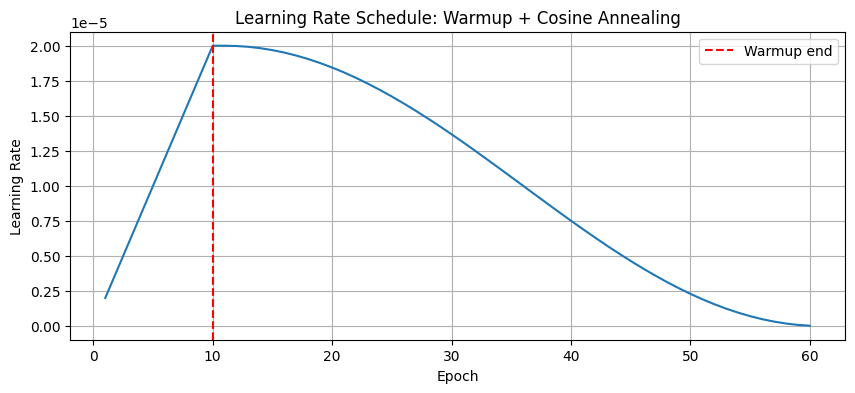

In [12]:
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt

WARMUP_EPOCHS = 10
TOTAL_EPOCHS = 60

def lr_lambda(epoch):
    # Epoch is 0-indexed in LambdaLR
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(WARMUP_EPOCHS)  # linearly from 0 to 1
    else:
        # Cosine annealing from 1 to 0 over remaining epochs
        progress = (epoch - WARMUP_EPOCHS) / max(1, TOTAL_EPOCHS - WARMUP_EPOCHS)
        return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
print(f"Using warmup ({WARMUP_EPOCHS} epochs) + cosine annealing scheduler.")

# Plot learning rate curve
lrs = [LEARNING_RATE * lr_lambda(e) for e in range(TOTAL_EPOCHS)]
plt.figure(figsize=(10, 4))
plt.plot(range(1, TOTAL_EPOCHS + 1), lrs)
plt.axvline(WARMUP_EPOCHS, color='r', linestyle='--', label='Warmup end')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule: Warmup + Cosine Annealing')
plt.legend()
plt.grid(True)
plt.show()


# Section 9: Training Loop with AMP and Gradient Clipping

This section defines `train_epoch()` and `evaluate()`, the core training and validation functions.

**Automatic Mixed Precision (AMP)** runs most forward/backward operations in float16 while keeping loss accumulation in float32. This reduces GPU memory and increases throughput without sacrificing numerical stability. **Gradient clipping** (`max_norm=10.0`) is applied because ASL can generate large gradients on hard negatives, and clipping prevents occasional gradient spikes. Batches that produce non-finite loss are skipped rather than updating the weights.

`evaluate()` runs the model in inference mode to collect logits and labels across the validation or test set; these are used for metrics and threshold optimization.

In [13]:
from tqdm import tqdm

scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

def train_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss = 0.0
    all_logits, all_labels = [], []
    for batch_idx, (images, labels) in enumerate(tqdm(loader, desc="Training")):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # Automatic Mixed Precision (AMP)
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)

            # Safety check: detect NaN/Inf loss before backward
            if not torch.isfinite(loss):
                print(f"\n🚨 WARNING: Non-finite loss ({loss.item():.2f}) at batch {batch_idx}")
                print("  Skipping batch...")
                scaler.update()
                continue

            scaler.scale(loss).backward()
            # Gradient clipping to prevent explosion from ASL
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)

            # Safety check: detect NaN/Inf loss before backward
            if not torch.isfinite(loss):
                print(f"\n🚨 WARNING: Non-finite loss ({loss.item():.2f}) at batch {batch_idx}")
                print("  Skipping batch...")
                continue

            loss.backward()
            # Gradient clipping to prevent explosion from ASL
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()

        total_loss += loss.item()
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.cpu())
    scheduler.step()  # step after each epoch
    avg_loss = total_loss / len(loader)
    all_logits = torch.cat(all_logits).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return avg_loss, all_logits, all_labels


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for images, labels in tqdm(loader, desc="Evaluating"):
        images = images.to(device)
        logits = model(images)
        all_logits.append(logits.cpu())
        all_labels.append(labels)
    return torch.cat(all_logits).numpy(), torch.cat(all_labels).numpy()

print("Training and evaluation functions defined.")


Training and evaluation functions defined.


# Section 10: Evaluation Metrics and Threshold Optimization

This section defines `compute_metrics()` and `find_optimal_thresholds()`. For medical screening, the relevant metrics are **AUC** (ranking quality independent of threshold), **F1** (balance between precision and recall on imbalanced classes), **precision** (fraction of predicted positives that are true disease cases), and **recall** (fraction of true disease cases that are detected). A single 0.5 threshold is rarely optimal across diseases with different prevalences, so thresholds are grid-searched from 0.05 to 0.95 on the validation set to maximize per-disease F1. **Macro F1**, the average of the four per-disease F1 scores, is the primary comparison metric because it gives equal weight to each disease regardless of prevalence.

In [14]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

def compute_metrics(logits, labels, thresholds=None):
    probs = 1 / (1 + np.exp(-logits))
    if thresholds is None:
        thresholds = {d: 0.5 for d in DISEASE_NAMES}
    metrics = {}
    for i, disease in enumerate(DISEASE_NAMES):
        y_true = labels[:, i]
        y_prob = probs[:, i]
        thr = thresholds.get(disease, 0.5)
        y_pred = (y_prob >= thr).astype(int)
        metrics[disease] = {
            'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
        }
    metrics['macro_f1'] = np.mean([m['f1'] for m in metrics.values()])
    # probs returned for optional downstream use; silence unused-variable warnings
    _ = probs
    return metrics, probs


def find_optimal_thresholds(logits, labels):
    probs = 1 / (1 + np.exp(-logits))
    thresholds = {}
    for i, disease in enumerate(DISEASE_NAMES):
        y_true = labels[:, i]
        y_prob = probs[:, i]
        best_f1, best_thr = 0, 0.5
        for thr in np.arange(0.05, 0.95, 0.01):
            y_pred = (y_prob >= thr).astype(int)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, thr
        thresholds[disease] = float(best_thr)
    return thresholds

print("compute_metrics and find_optimal_thresholds defined.")


compute_metrics and find_optimal_thresholds defined.


# Section 11: Test Set Evaluation and Results Aggregation

This section defines `run_test_evaluation()`, which loads the best checkpoint and evaluates it on the held-out test sets. Keeping evaluation in a separate function makes it reusable after training or from another notebook without re-running the full loop.

Two test sets are used:
- **`test_v4`** (1,407 images): same distribution as the previous v3 model, enabling direct comparison.
- **`test_v4_extended`** (5,339 images): a larger, more diverse held-out set for publication-grade results.

The function writes `results.json`, containing the best epoch, best validation macro F1, optimal thresholds, and per-disease AUC, F1, precision, and recall for each test set. This file is the main artifact for reporting and downstream analysis.

In [15]:
def run_test_evaluation(model, run_dir, test_csv, test_loader_obj, test_extended_csv=None):
    """Evaluate best model on test sets and save results."""
    print("\nLoading best model for test evaluation...")
    best_checkpoint = torch.load(f"{run_dir}/best_model.pth", map_location=device, weights_only=False)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    model.eval()

    final_thresholds = best_checkpoint['optimal_thresholds']

    # Evaluate on both test sets
    test_configs = [("test_v4", test_csv, test_loader_obj)]

    # Add extended test set if available
    if test_extended_csv and test_extended_csv.exists():
        test_extended_df = pd.read_csv(test_extended_csv)
        test_extended_dataset = UnifiedDataset(test_extended_df, img_root, DISEASE_NAMES, IMG_SIZE, is_train=False)
        test_extended_loader = DataLoader(
            test_extended_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )
        test_configs.append(("test_v4_extended", test_extended_csv, test_extended_loader))
        print(f"Extended test set: {len(test_extended_df)} images")
    else:
        print(f"Extended test CSV not found or not provided, skipping")

    all_test_results = {}

    for test_name, test_csv_path, test_loader_obj in test_configs:
        print(f"\n{'─'*40}")
        print(f"  {test_name}")
        print(f"{'─'*40}")

        test_logits, test_labels = evaluate(model, test_loader_obj)
        test_metrics, _ = compute_metrics(test_logits, test_labels, final_thresholds)

        print(f"\n  {test_name} — {len(pd.read_csv(test_csv_path))} images")
        print(f"  Macro F1: {test_metrics['macro_f1']:.4f}")
        for d in DISEASE_NAMES:
            m = test_metrics[d]
            print(f"    {d:12s} AUC={m['auc']:.4f} F1={m['f1']:.4f} P={m['precision']:.4f} R={m['recall']:.4f}")

        all_test_results[test_name] = {
            'num_images': len(pd.read_csv(test_csv_path)),
            'metrics': test_metrics,
        }

    # Save results
    results = {
        'best_epoch': best_checkpoint.get('epoch', 0),
        'best_val_tune_f1': best_checkpoint.get('best_val_f1', 0.0),
        'optimal_thresholds': final_thresholds,
        'test_results': all_test_results,
    }
    with open(f"{run_dir}/results.json", 'w') as f:
        json.dump(results, f, indent=2, default=str)

    print(f"\nTraining complete. Results saved to {run_dir}/")
    return results

print("run_test_evaluation defined.")


run_test_evaluation defined.


# Section 12: Checkpoint Saving, SafeTensor Export, and Full Training Loop

This section runs the complete training loop, including checkpoint initialization/resumption, per-epoch validation, and model selection. Every epoch saves `latest_model.pth` (for resuming after a Colab disconnect), `best_model.pth` (the checkpoint with the highest validation macro F1), `best_model.safetensors` (a pickle-free SafeTensors copy), `config.json` (hyperparameters), and `training_history.json` (per-epoch metrics). Resume support is essential for Colab, where sessions can time out; if `latest_model.pth` exists, training continues from that epoch. Early stopping halts training after 10 epochs without validation-macro-F1 improvement to prevent overfitting and save compute. All artifacts are written directly to Google Drive because Colab's local disk is ephemeral.

In [16]:
try:
    import safetensors.torch as _safetensors_torch
    save_file = _safetensors_torch.save_file
except Exception:  # pragma: no cover
    _safetensors_torch = None  # type: ignore
    save_file = None

# ═══════════════════════════════════════════════════════════════
# Training configuration — checkpoints saved to Drive
# ═══════════════════════════════════════════════════════════════
MODEL_NAME = "glaam4x_unified_v4_asl_384"
RUN_DIR = f"{DRIVE_BASE}/checkpoints/{MODEL_NAME}"
os.makedirs(RUN_DIR, exist_ok=True)

with open(f"{RUN_DIR}/config.json", 'w') as f:
    json.dump({
        "model_name": MODEL_NAME,
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "dropout_rate": DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "epochs": TOTAL_EPOCHS,
        "warmup_epochs": WARMUP_EPOCHS,
        "asl_gamma_neg": ASL_GAMMA_NEG,
        "asl_gamma_pos": ASL_GAMMA_POS,
        "asl_clip": ASL_CLIP,
    }, f, indent=2)

# Resume support
start_epoch = 1
best_val_f1 = 0.0
best_epoch = 0
patience = 10
patience_counter = 0
latest_ckpt_path = os.path.join(RUN_DIR, "latest_model.pth")

# Training history tracker
history = {
    'epoch': [], 'lr': [],
    'train_loss': [], 'train_macro_f1': [],
    'val_loss': [], 'val_macro_f1': [], 'val_macro_f1_opt': [],
    'val_auc': {d: [] for d in DISEASE_NAMES},
    'val_f1': {d: [] for d in DISEASE_NAMES},
    'val_precision': {d: [] for d in DISEASE_NAMES},
    'val_recall': {d: [] for d in DISEASE_NAMES},
}

if os.path.exists(latest_ckpt_path):
    print(f"Found checkpoint {latest_ckpt_path}, resuming...")
    ckpt = torch.load(latest_ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt.get('epoch', 0) + 1
    best_val_f1 = ckpt.get('best_val_f1', 0.0)
    patience_counter = ckpt.get('patience_counter', 0)
    scheduler = LambdaLR(optimizer, lr_lambda, last_epoch=start_epoch - 1)
    # Restore history if available
    if 'history' in ckpt:
        history = ckpt['history']
    print(f"Resumed at epoch {start_epoch} | Best val F1 so far: {best_val_f1:.4f}")
else:
    print("No checkpoint found, starting from scratch.")

# ═══════════════════════════════════════════════════════════════
# Full Training Loop
# ═══════════════════════════════════════════════════════════════
print("\nStarting training...")
for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    print(f"\n{'='*60}")
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{TOTAL_EPOCHS} | LR: {current_lr:.2e}")
    print(f"{'='*60}")

    train_loss, train_logits, train_labels = train_epoch(model, train_loader, criterion, optimizer, scheduler)
    train_metrics, _ = compute_metrics(train_logits, train_labels)

    # Validation on tuning set
    val_logits, val_labels = evaluate(model, val_tune_loader)
    val_metrics, _ = compute_metrics(val_logits, val_labels)
    optimal_thresholds = find_optimal_thresholds(val_logits, val_labels)
    val_metrics_opt, _ = compute_metrics(val_logits, val_labels, optimal_thresholds)

    # Compute validation loss for plotting
    val_loss = criterion(
        torch.tensor(val_logits, dtype=torch.float32),
        torch.tensor(val_labels, dtype=torch.float32),
    ).item()

    print(f"Train Loss: {train_loss:.4f} | Val Tune Macro F1: {val_metrics['macro_f1']:.4f} (thr=0.5)")
    print(f"Val Tune Macro F1 (optimal thr): {val_metrics_opt['macro_f1']:.4f}")
    for d in DISEASE_NAMES:
        m = val_metrics_opt[d]
        print(f"  {d:12s} AUC={m['auc']:.4f} F1={m['f1']:.4f} P={m['precision']:.4f} R={m['recall']:.4f} thr={optimal_thresholds[d]:.2f}")

    # Record history
    history['epoch'].append(epoch)
    history['lr'].append(current_lr)
    history['train_loss'].append(train_loss)
    history['train_macro_f1'].append(train_metrics['macro_f1'])
    history['val_loss'].append(val_loss)  # Now computed from val logits
    history['val_macro_f1'].append(val_metrics['macro_f1'])
    history['val_macro_f1_opt'].append(val_metrics_opt['macro_f1'])
    for d in DISEASE_NAMES:
        history['val_auc'][d].append(val_metrics_opt[d]['auc'])
        history['val_f1'][d].append(val_metrics_opt[d]['f1'])
        history['val_precision'][d].append(val_metrics_opt[d]['precision'])
        history['val_recall'][d].append(val_metrics_opt[d]['recall'])

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_metrics_opt': val_metrics_opt,
        'optimal_thresholds': optimal_thresholds,
        'best_val_f1': best_val_f1,
        'patience_counter': patience_counter,
        'history': history,
    }

    if val_metrics_opt['macro_f1'] > best_val_f1:
        best_val_f1 = val_metrics_opt['macro_f1']
        best_epoch = epoch
        patience_counter = 0
        torch.save(checkpoint, f"{RUN_DIR}/best_model.pth")
        if save_file is not None:
            save_file(model.state_dict(), f"{RUN_DIR}/best_model.safetensors")
            print(f"New best model saved (tune macro F1 = {best_val_f1:.4f})")
        else:
            print(f"New best model saved (tune macro F1 = {best_val_f1:.4f}) — safetensors unavailable")
    else:
        patience_counter += 1

    torch.save(checkpoint, f"{RUN_DIR}/latest_model.pth")

    if patience_counter >= patience:
        print(f"Early stopping triggered after {patience} epochs without improvement")
        break


print(f"\nTraining complete. Best val F1: {best_val_f1:.4f} at epoch {best_epoch}")

# Save history to Drive for later plotting
import json as _json
history_path = f"{RUN_DIR}/training_history.json"
with open(history_path, 'w') as f:
    _json.dump(history, f, indent=2)
print(f"Training history saved to {history_path}")


Found checkpoint /content/drive/MyDrive/Backup/dataset/cataract_detection/checkpoints/glaam4x_unified_v4_asl_384/latest_model.pth, resuming...
Resumed at epoch 52 | Best val F1 so far: 0.8304

Starting training...

Epoch 52/60 | LR: 1.24e-06


Evaluating: 100%|██████████| 105/105 [03:24<00:00,  1.95s/it]


Train Loss: 0.0396 | Val Tune Macro F1: 0.8201 (thr=0.5)
Val Tune Macro F1 (optimal thr): 0.8293
  Cataract     AUC=0.9927 F1=0.9073 P=0.9282 R=0.8873 thr=0.53
  DR           AUC=0.9566 F1=0.8629 P=0.8680 R=0.8578 thr=0.45
  Glaucoma     AUC=0.9697 F1=0.7244 P=0.8288 R=0.6434 thr=0.53
  Myopia       AUC=0.9821 F1=0.8226 P=0.8361 R=0.8095 thr=0.48

Epoch 53/60 | LR: 9.52e-07


Training:  17%|█▋        | 234/1394 [09:48<48:36,  2.51s/it]


KeyboardInterrupt: 

# Section 12b: Training Visualization Graphs

This section generates publication-quality plots from the saved training history and the best-epoch validation predictions. The eleven figures are: training loss, macro F1 progression (train vs. validation with fixed and optimal thresholds), per-disease validation AUC, per-disease validation F1, per-disease precision-recall trends, the actual learning-rate schedule, a combined dashboard, train-vs-validation loss (for overfitting detection), per-disease ROC curves, per-disease precision-recall curves, and per-disease confusion matrices at optimal thresholds. Together they show whether the model is learning, whether overfitting is occurring, how each disease's discriminative and calibrated performance evolves, and the final false-positive/false-negative trade-offs. All figures are saved at 300 DPI under `checkpoints/glaam4x_unified_v4_asl_384/training_graphs/`.

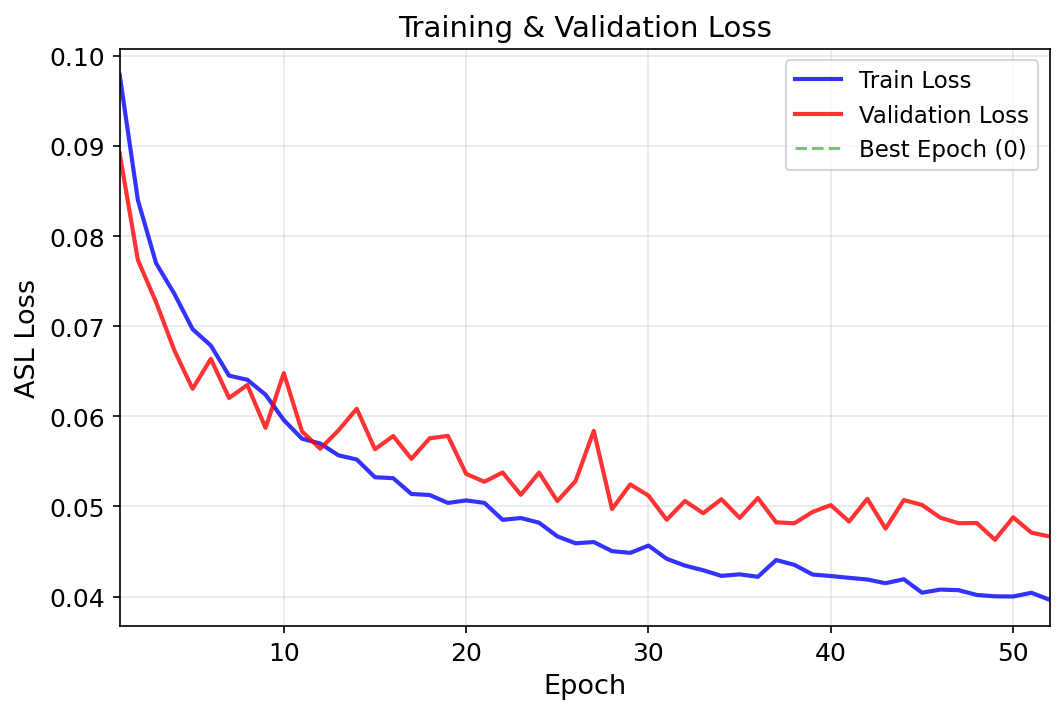

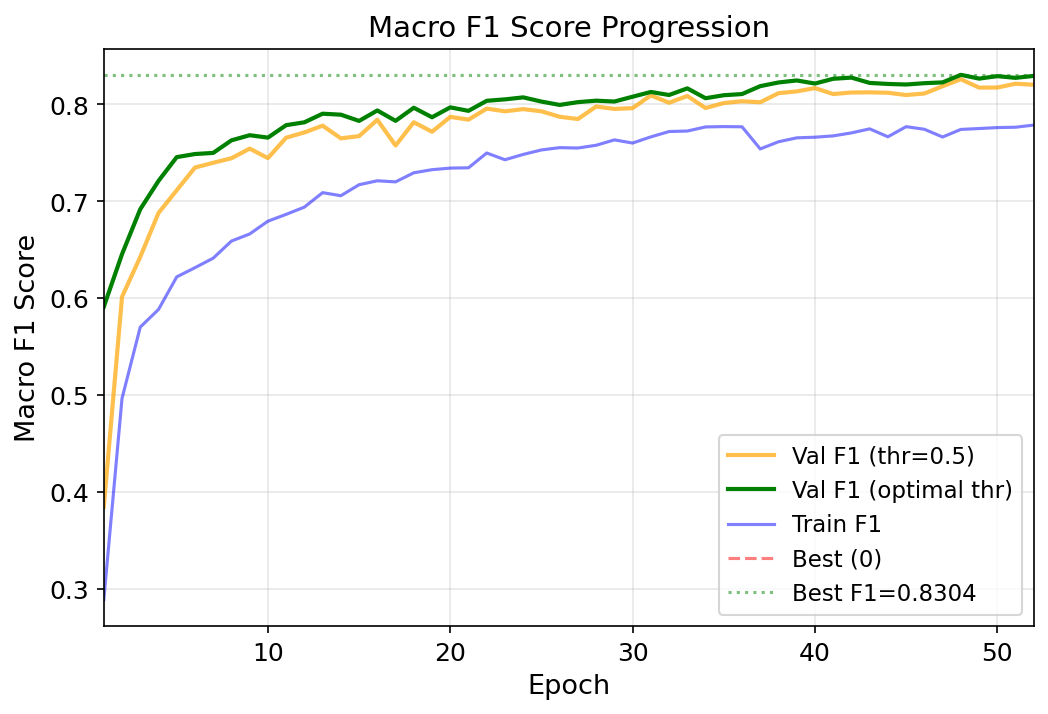

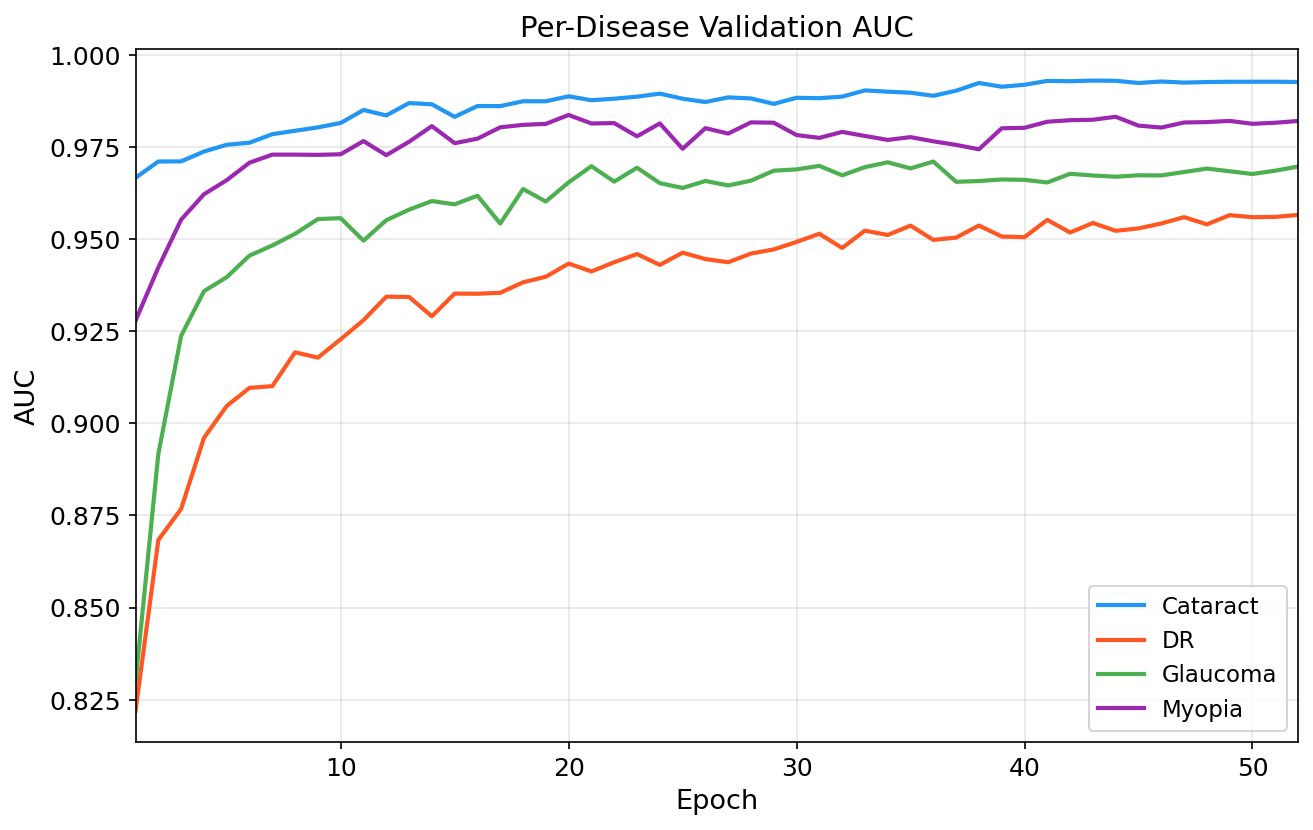

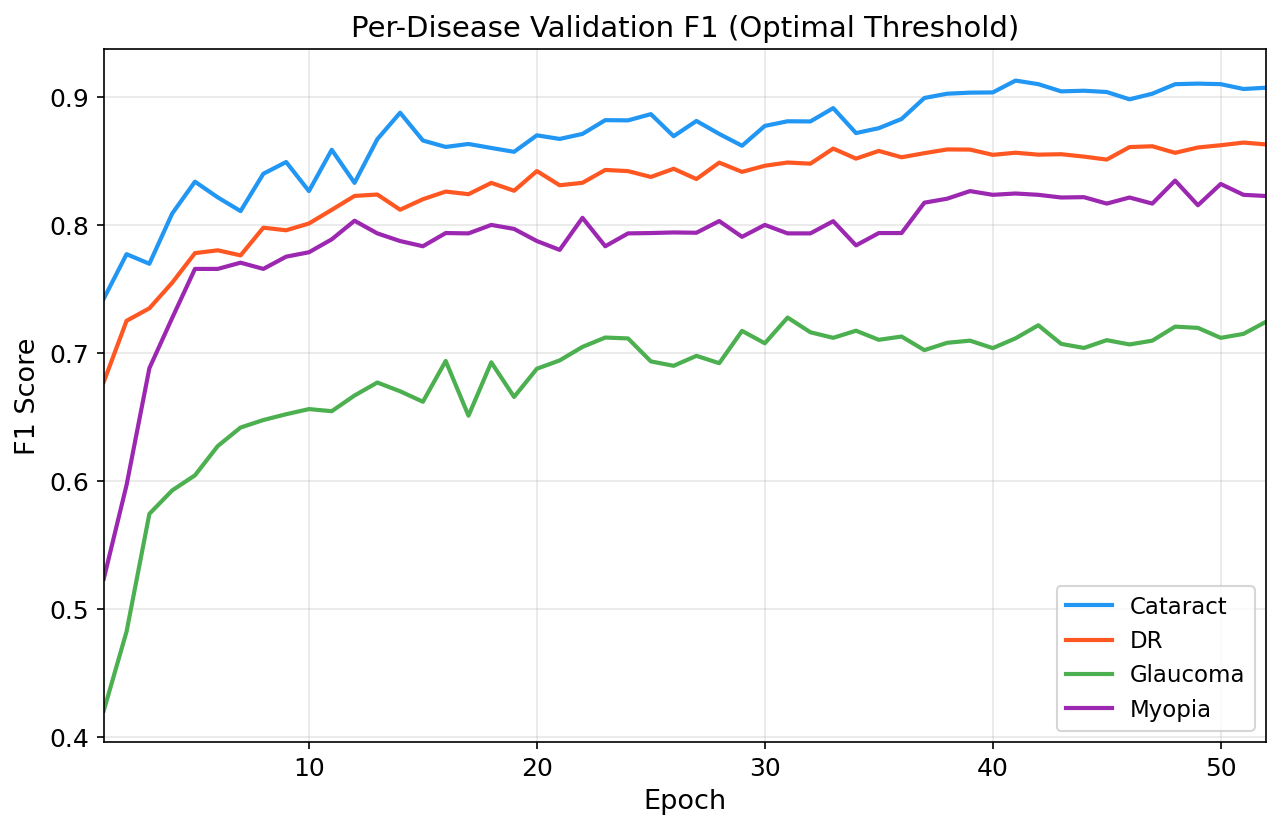

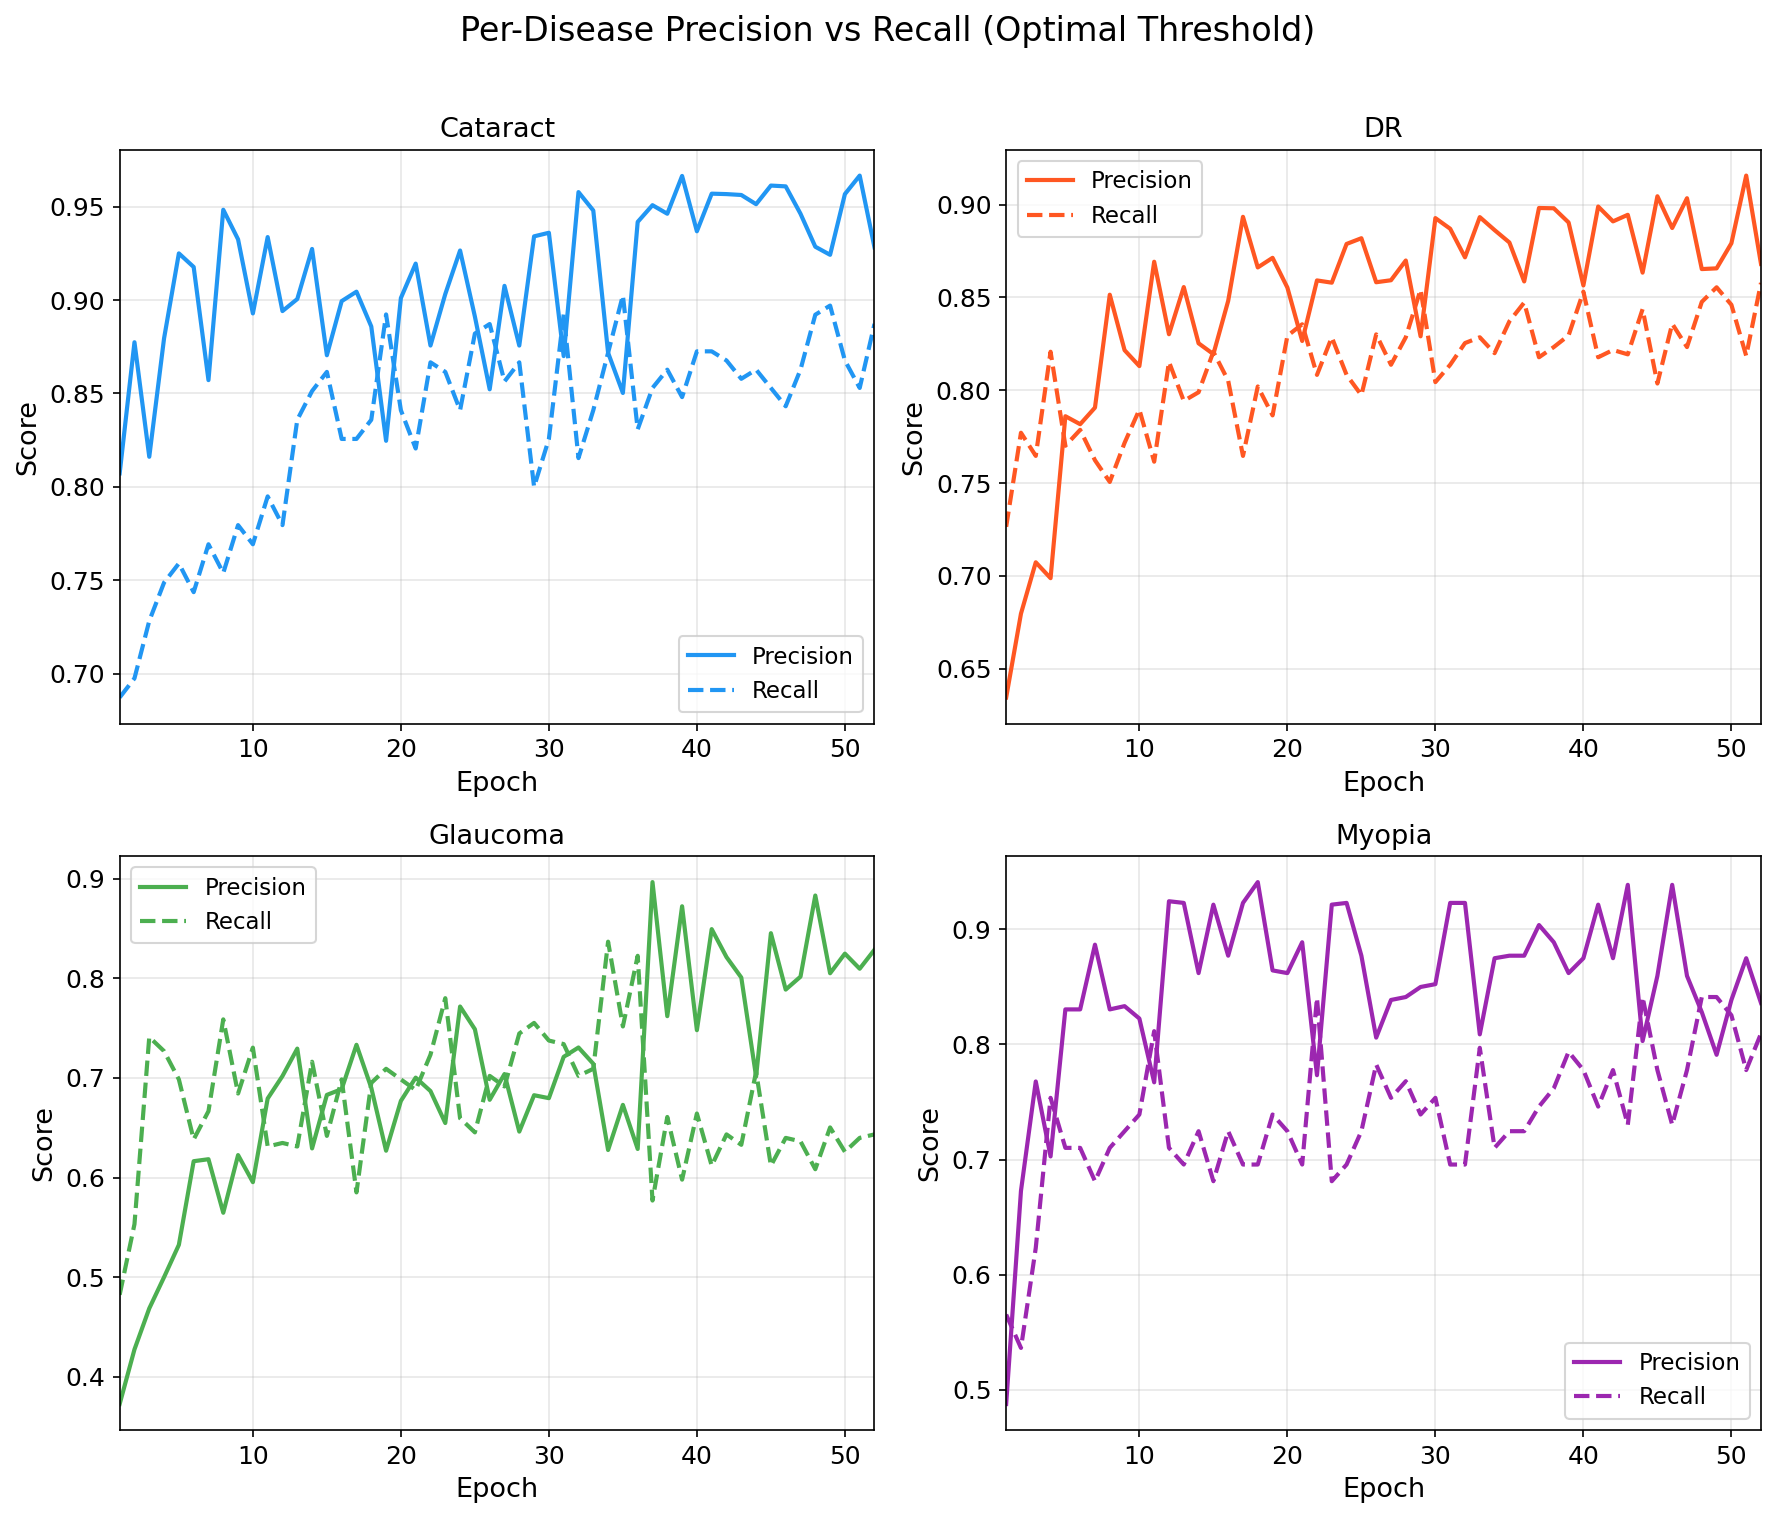

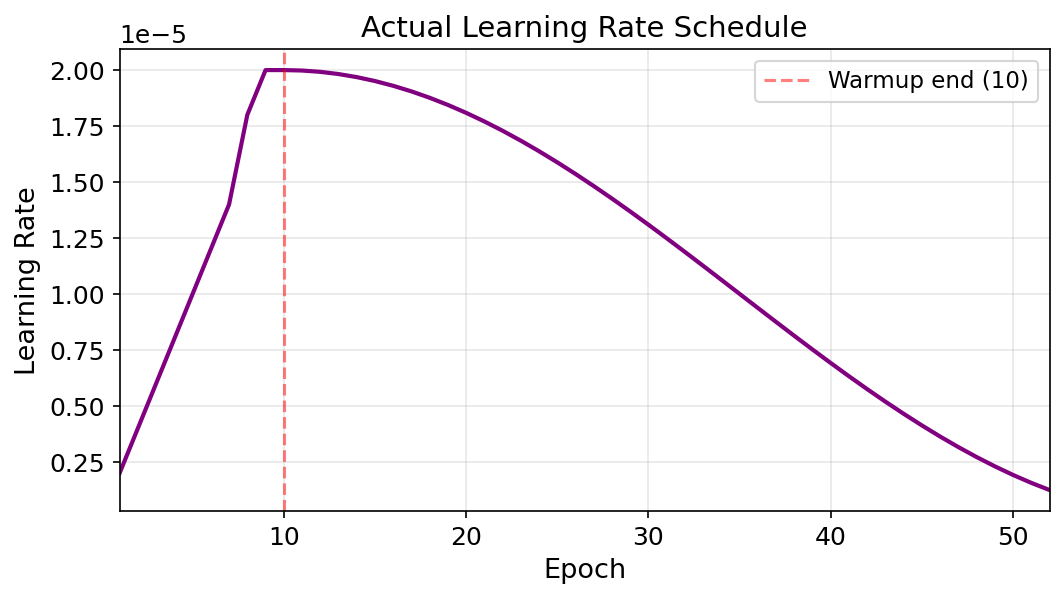

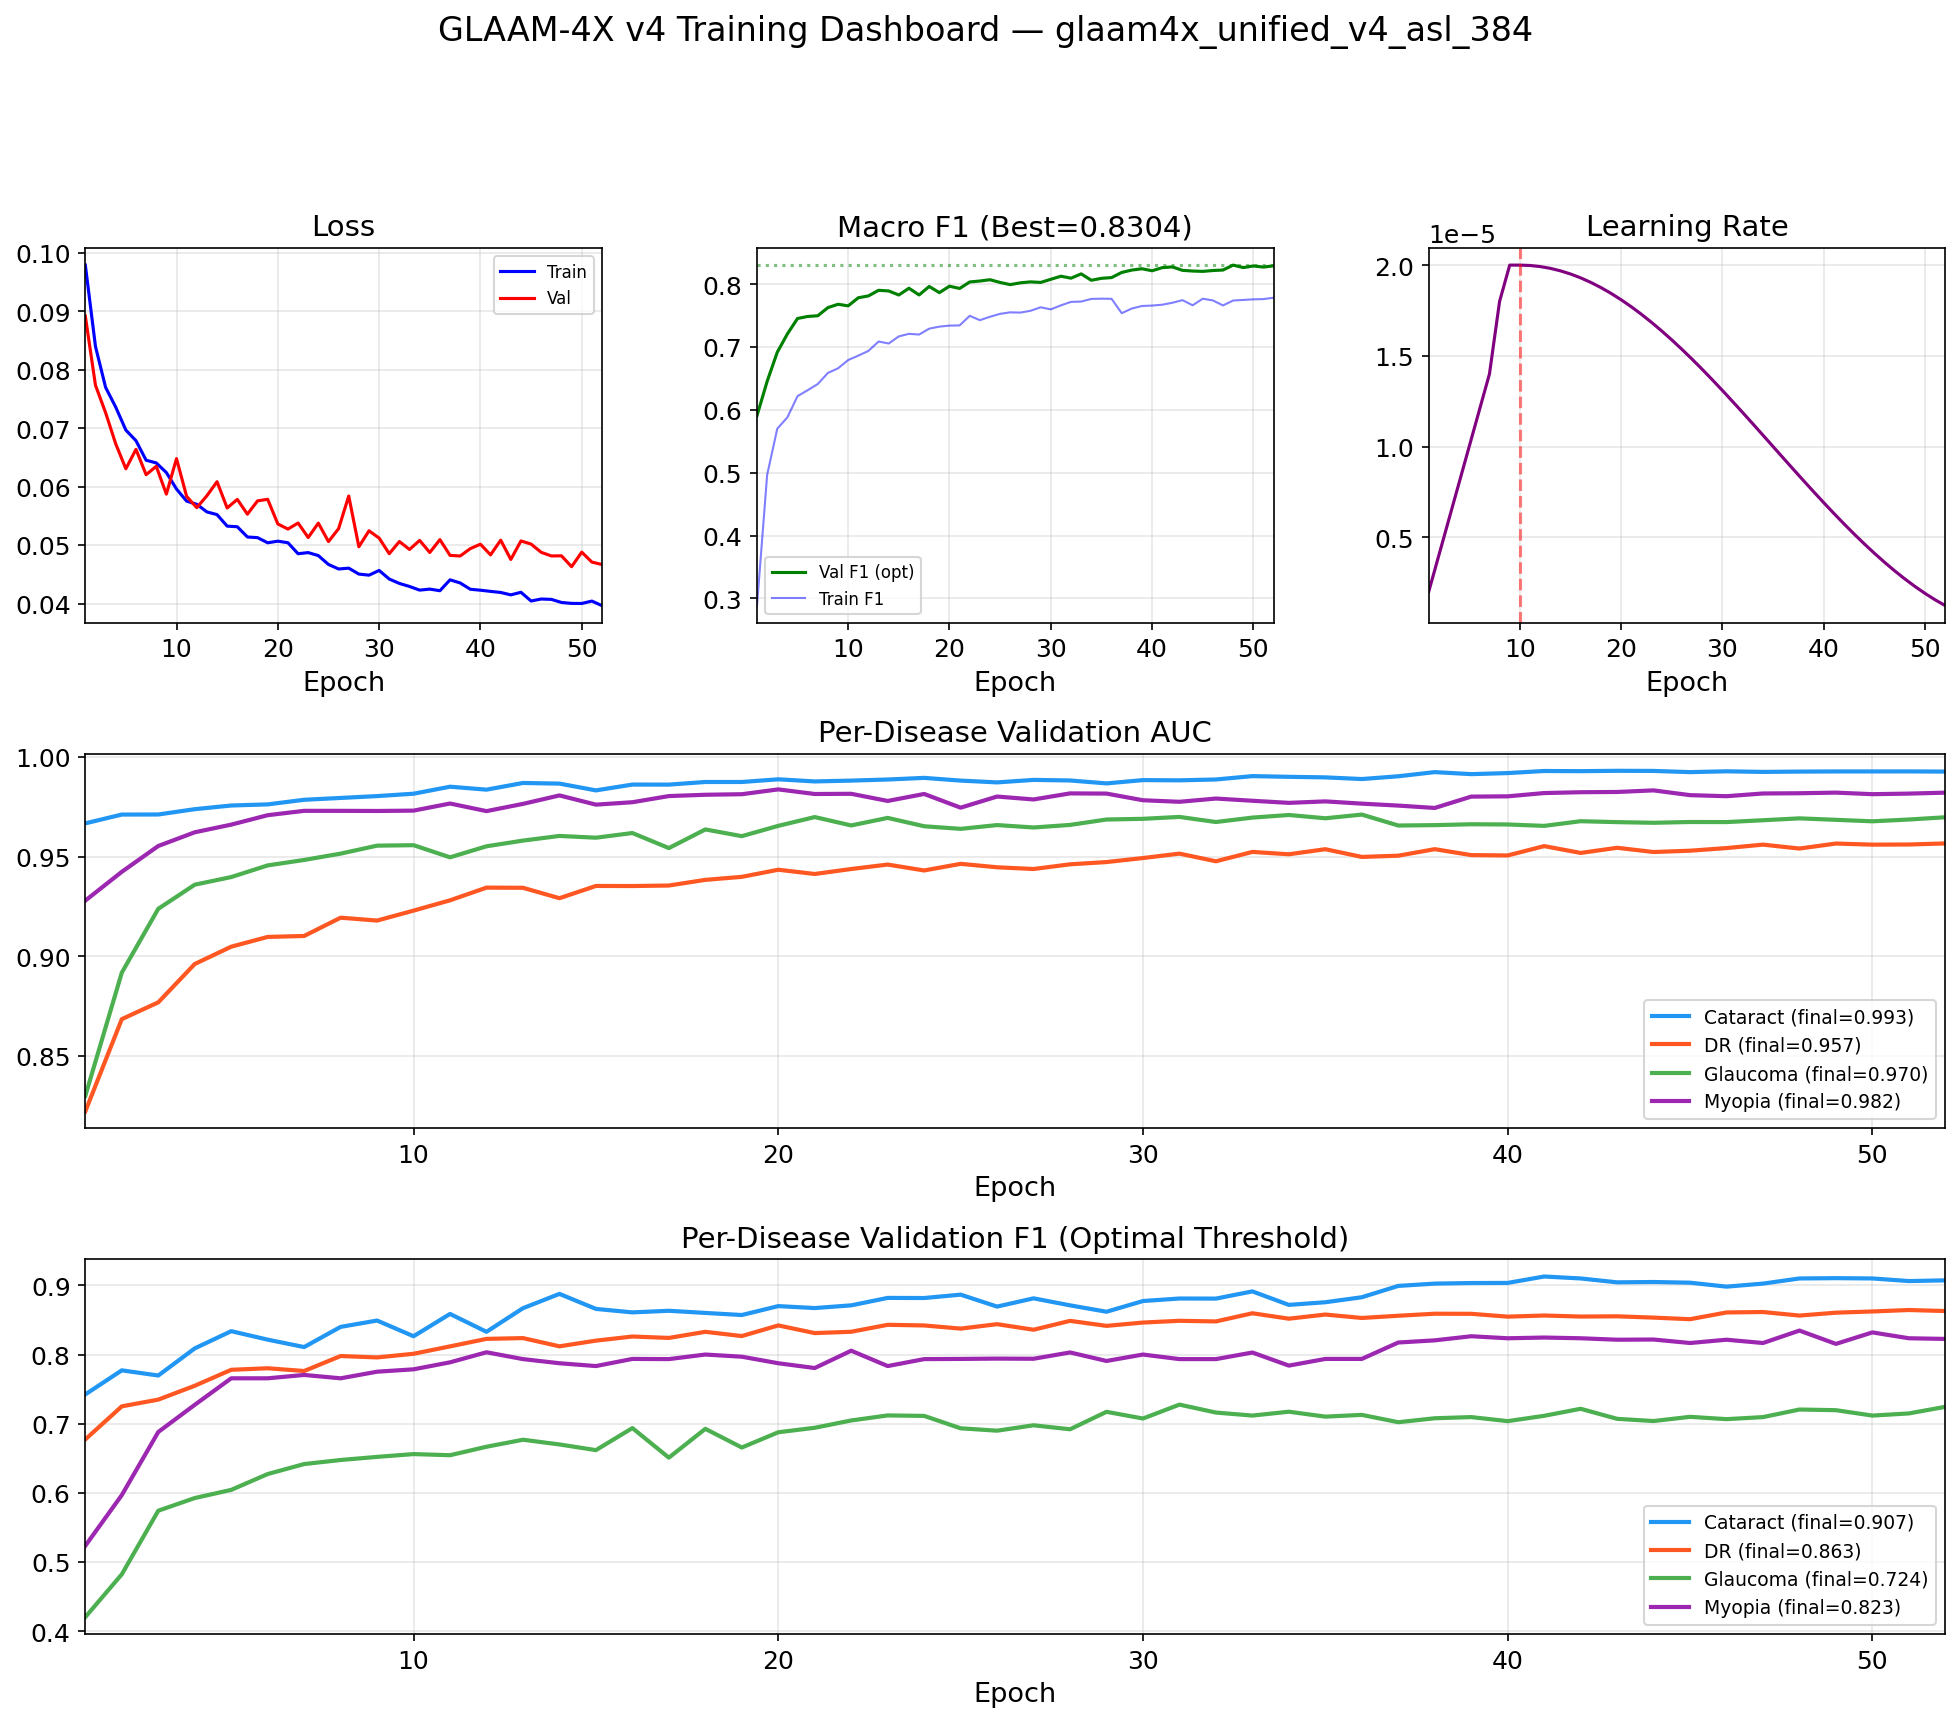

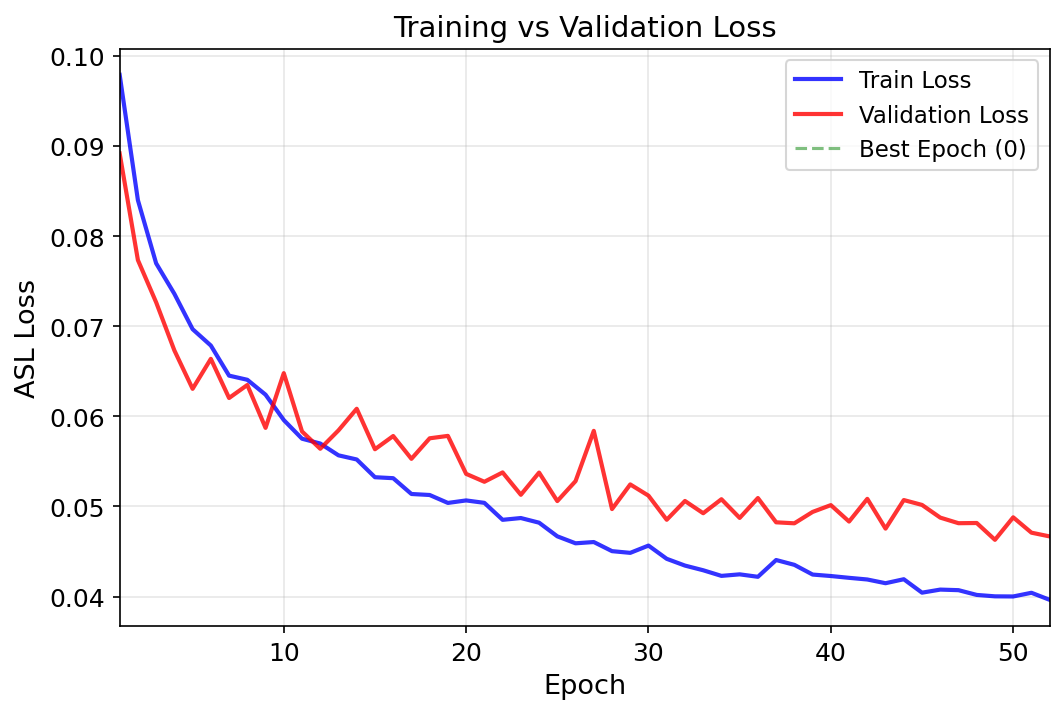

Evaluating: 100%|██████████| 105/105 [02:28<00:00,  1.42s/it]


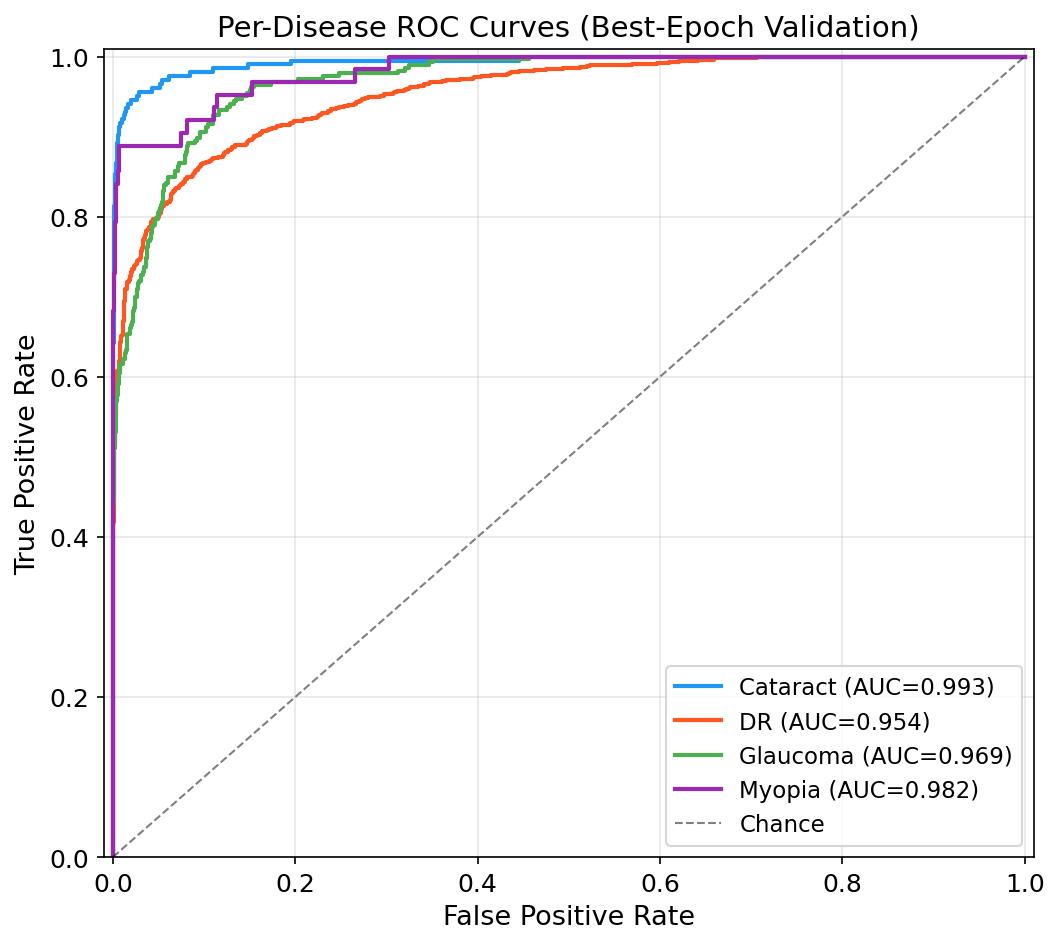

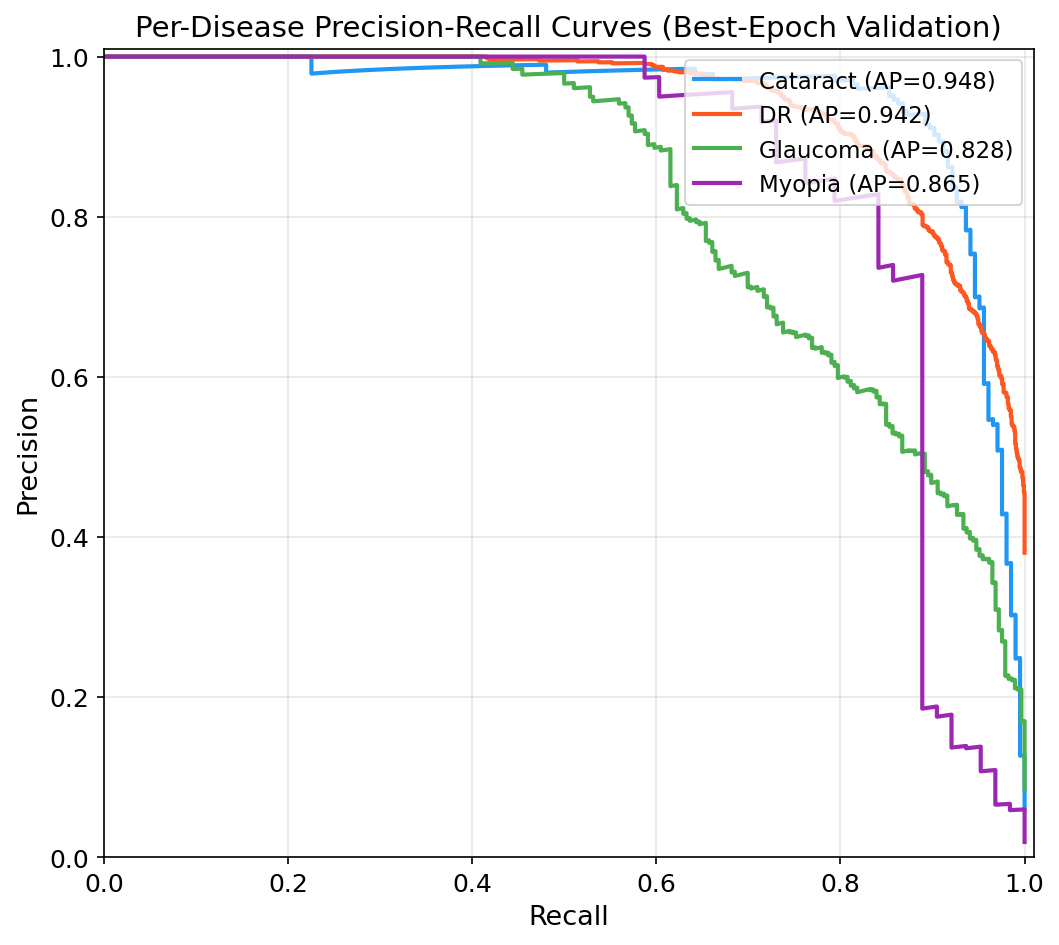

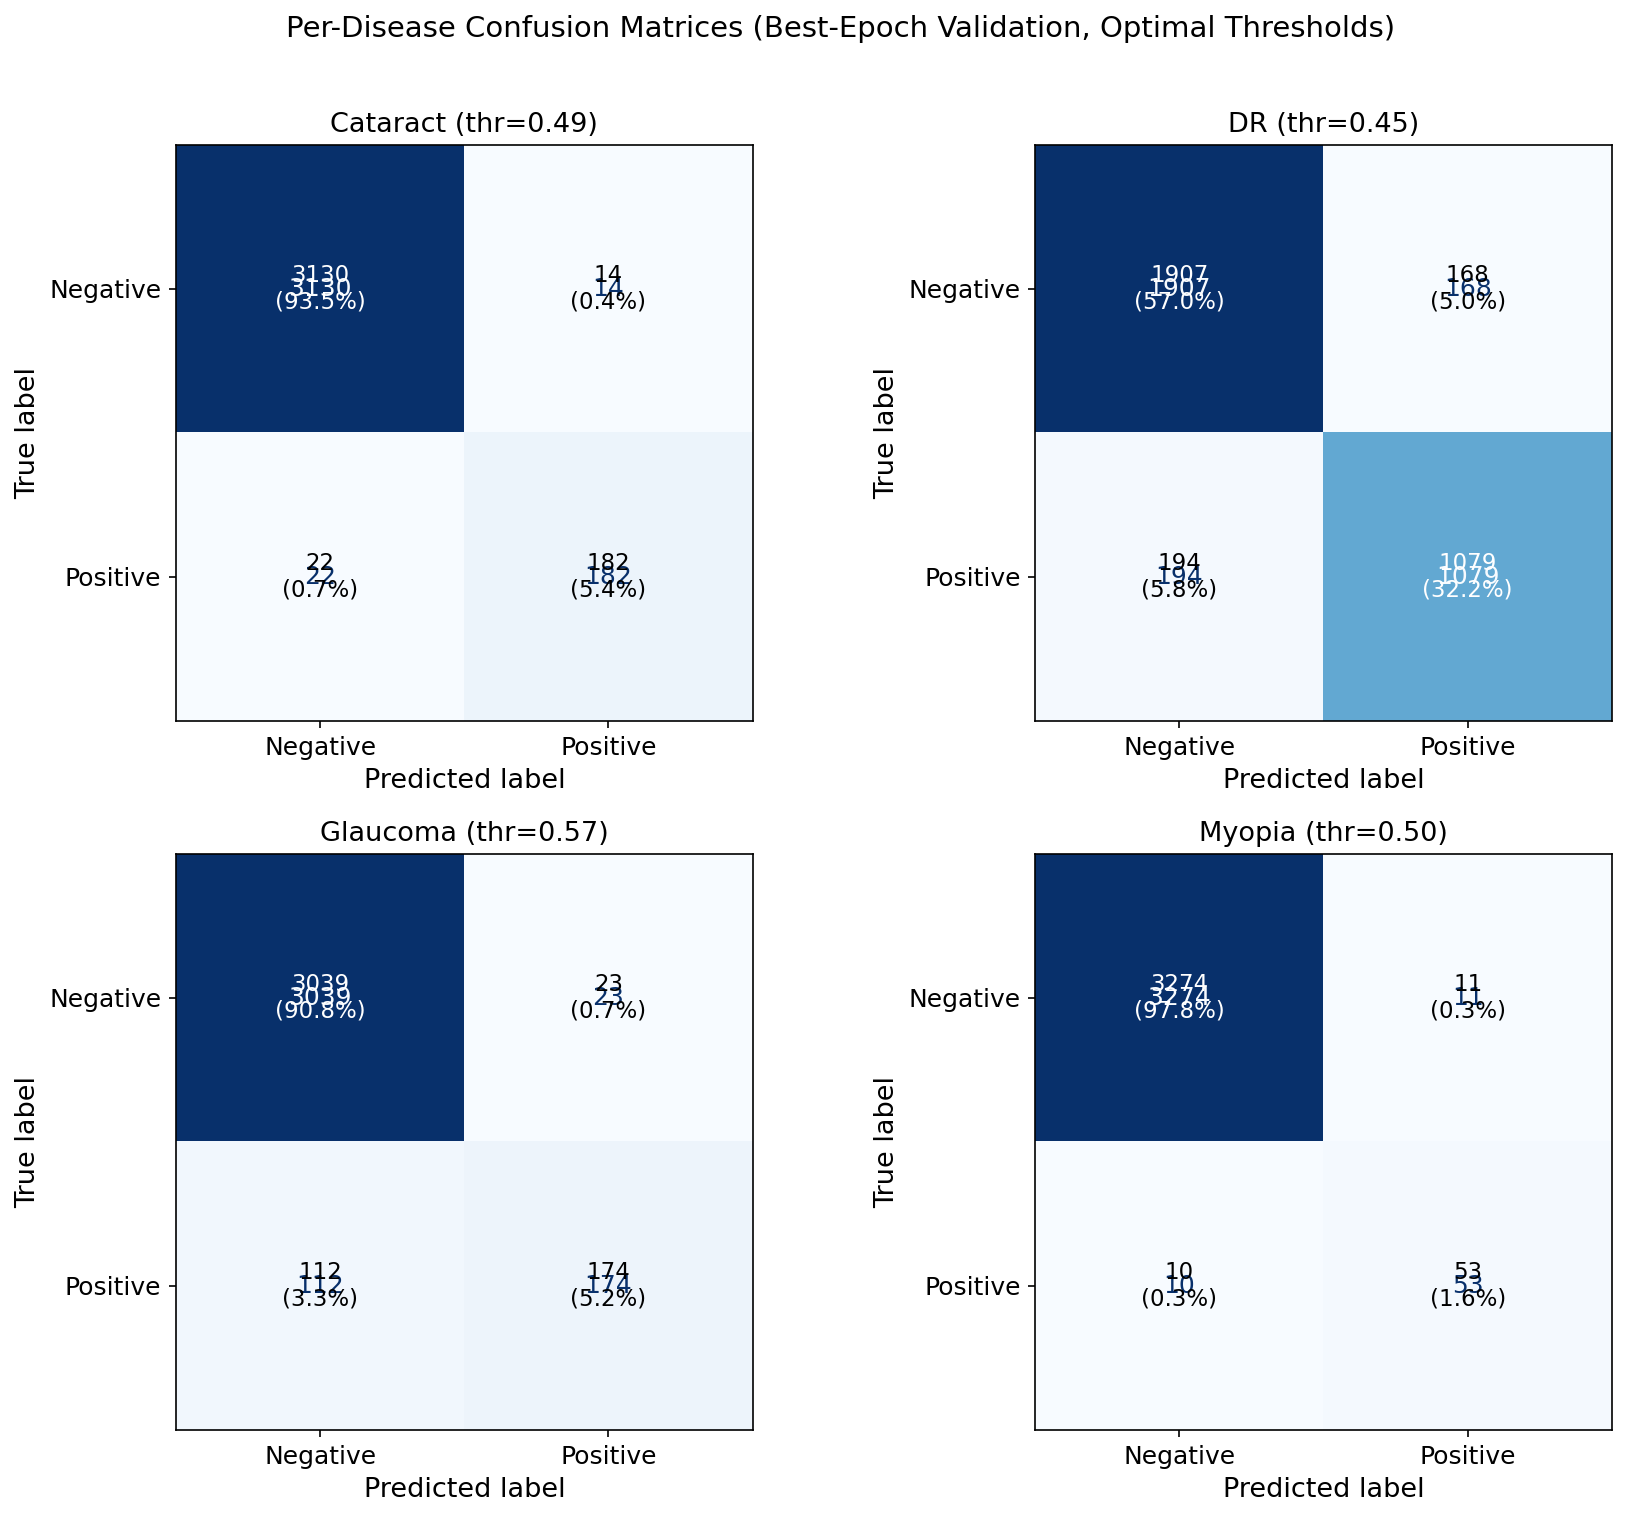


📊 TRAINING GRAPHS SAVED
Location: /content/drive/MyDrive/Backup/dataset/cataract_detection/checkpoints/glaam4x_unified_v4_asl_384/training_graphs/
Files:
  01_loss_curve.png
  02_macro_f1_progression.png
  03_per_disease_auc.png
  04_per_disease_f1.png
  05_precision_recall.png
  06_lr_schedule.png
  07_dashboard.png
  08_train_val_loss.png
  09_roc_curves.png
  10_pr_curves.png
  11_confusion_matrices.png


In [17]:
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════
# Publication-quality training graphs
# ═══════════════════════════════════════════════════════════════

GRAPHS_DIR = f"{RUN_DIR}/training_graphs"
os.makedirs(GRAPHS_DIR, exist_ok=True)

# Style settings for publication
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})

epochs = history['epoch']
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']  # Blue, Orange, Green, Purple

# ─────────────────────────────────────────────────────────────
# Graph 1: Loss Curve (Train + Validation)
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train Loss', alpha=0.8)
ax.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Validation Loss', alpha=0.8)
ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('ASL Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, max(epochs))
fig.savefig(f"{GRAPHS_DIR}/01_loss_curve.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 2: Macro F1 Progression
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history['val_macro_f1'], 'orange', linewidth=2, label='Val F1 (thr=0.5)', alpha=0.7)
ax.plot(epochs, history['val_macro_f1_opt'], 'green', linewidth=2, label='Val F1 (optimal thr)')
ax.plot(epochs, history['train_macro_f1'], 'blue', linewidth=1.5, label='Train F1', alpha=0.5)
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best ({best_epoch})')
ax.axhline(best_val_f1, color='green', linestyle=':', alpha=0.5, label=f'Best F1={best_val_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro F1 Score')
ax.set_title('Macro F1 Score Progression')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, max(epochs))
fig.savefig(f"{GRAPHS_DIR}/02_macro_f1_progression.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 3: Per-Disease AUC Curves
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, d in enumerate(DISEASE_NAMES):
    ax.plot(epochs, history['val_auc'][d], linewidth=2, color=colors[i], label=d)
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Per-Disease Validation AUC')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, max(epochs))
fig.savefig(f"{GRAPHS_DIR}/03_per_disease_auc.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 4: Per-Disease F1 Curves
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, d in enumerate(DISEASE_NAMES):
    ax.plot(epochs, history['val_f1'][d], linewidth=2, color=colors[i], label=d)
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Disease Validation F1 (Optimal Threshold)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, max(epochs))
fig.savefig(f"{GRAPHS_DIR}/04_per_disease_f1.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 5: Precision-Recall per Disease
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, d in enumerate(DISEASE_NAMES):
    ax = axes[i]
    ax.plot(epochs, history['val_precision'][d], color=colors[i], linewidth=2, linestyle='-', label='Precision')
    ax.plot(epochs, history['val_recall'][d], color=colors[i], linewidth=2, linestyle='--', label='Recall')
    ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
    ax.set_title(d, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, max(epochs))
fig.suptitle('Per-Disease Precision vs Recall (Optimal Threshold)', fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(f"{GRAPHS_DIR}/05_precision_recall.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 6: Learning Rate Schedule (Actual)
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, history['lr'], 'purple', linewidth=2)
ax.axvline(WARMUP_EPOCHS, color='red', linestyle='--', alpha=0.5, label=f'Warmup end ({WARMUP_EPOCHS})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Actual Learning Rate Schedule')
ax.legend()
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax.set_xlim(1, max(epochs))
fig.savefig(f"{GRAPHS_DIR}/06_lr_schedule.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 7: Combined Dashboard
# ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, history['train_loss'], 'b-', linewidth=1.5, label='Train')
ax1.plot(epochs, history['val_loss'], 'r-', linewidth=1.5, label='Val')
ax1.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, max(epochs))

# Macro F1
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, history['val_macro_f1_opt'], 'green', linewidth=1.5, label='Val F1 (opt)')
ax2.plot(epochs, history['train_macro_f1'], 'blue', linewidth=1, alpha=0.5, label='Train F1')
ax2.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
ax2.axhline(best_val_f1, color='green', linestyle=':', alpha=0.5)
ax2.set_title(f'Macro F1 (Best={best_val_f1:.4f})')
ax2.set_xlabel('Epoch')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, max(epochs))

# LR
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, history['lr'], 'purple', linewidth=1.5)
ax3.axvline(WARMUP_EPOCHS, color='red', linestyle='--', alpha=0.5)
ax3.set_title('Learning Rate')
ax3.set_xlabel('Epoch')
ax3.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax3.grid(True, alpha=0.3)
ax3.set_xlim(1, max(epochs))

# Per-disease AUC
ax4 = fig.add_subplot(gs[1, :])
for i, d in enumerate(DISEASE_NAMES):
    ax4.plot(epochs, history['val_auc'][d], linewidth=2, color=colors[i], label=f'{d} (final={history["val_auc"][d][-1]:.3f})')
ax4.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
ax4.set_title('Per-Disease Validation AUC')
ax4.set_xlabel('Epoch')
ax4.legend(loc='lower right', fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(1, max(epochs))

# Per-disease F1
ax5 = fig.add_subplot(gs[2, :])
for i, d in enumerate(DISEASE_NAMES):
    ax5.plot(epochs, history['val_f1'][d], linewidth=2, color=colors[i], label=f'{d} (final={history["val_f1"][d][-1]:.3f})')
ax5.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
ax5.set_title('Per-Disease Validation F1 (Optimal Threshold)')
ax5.set_xlabel('Epoch')
ax5.legend(loc='lower right', fontsize=9)
ax5.grid(True, alpha=0.3)
ax5.set_xlim(1, max(epochs))

fig.suptitle(f'GLAAM-4X v4 Training Dashboard — {MODEL_NAME}', fontsize=16, y=1.01)
fig.savefig(f"{GRAPHS_DIR}/07_dashboard.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 8: Train vs Validation Loss
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train Loss', alpha=0.8)
ax.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Validation Loss', alpha=0.8)
ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('ASL Loss')
ax.set_title('Training vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, max(epochs))
fig.savefig(f"{GRAPHS_DIR}/08_train_val_loss.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 9: ROC Curves (per disease, from best-epoch validation)
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc as sk_auc

# Re-evaluate on validation set with best model to get final-epoch logits
best_ckpt_for_roc = torch.load(f"{RUN_DIR}/best_model.pth", map_location=device, weights_only=False)
model.load_state_dict(best_ckpt_for_roc['model_state_dict'])
model.eval()
roc_logits, roc_labels = evaluate(model, val_tune_loader)
roc_probs = 1 / (1 + np.exp(-roc_logits))

fig, ax = plt.subplots(figsize=(8, 7))
for i, d in enumerate(DISEASE_NAMES):
    y_true = roc_labels[:, i]
    y_prob = roc_probs[:, i]
    if len(np.unique(y_true)) > 1:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, color=colors[i], label=f'{d} (AUC={roc_auc:.3f})')
    else:
        ax.plot([], [], linewidth=2, color=colors[i], label=f'{d} (N/A — single class)')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Per-Disease ROC Curves (Best-Epoch Validation)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(0.0, 1.01)
fig.savefig(f"{GRAPHS_DIR}/09_roc_curves.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 10: Precision-Recall Curves (per disease, best-epoch val)
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 7))
for i, d in enumerate(DISEASE_NAMES):
    y_true = roc_labels[:, i]
    y_prob = roc_probs[:, i]
    if len(np.unique(y_true)) > 1:
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        ax.plot(rec, prec, linewidth=2, color=colors[i], label=f'{d} (AP={ap:.3f})')
    else:
        ax.plot([], [], linewidth=2, color=colors[i], label=f'{d} (N/A — single class)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Per-Disease Precision-Recall Curves (Best-Epoch Validation)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.0, 1.01)
ax.set_ylim(0.0, 1.01)
fig.savefig(f"{GRAPHS_DIR}/10_pr_curves.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# Graph 11: Confusion Matrices (per disease, optimal threshold)
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
final_thresholds = best_ckpt_for_roc.get('optimal_thresholds', {d: 0.5 for d in DISEASE_NAMES})
for i, d in enumerate(DISEASE_NAMES):
    ax = axes[i]
    y_true = roc_labels[:, i].astype(int)
    y_prob = roc_probs[:, i]
    thr = final_thresholds.get(d, 0.5)
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    # Build labels with both count and percentage
    cm_total = cm.sum()
    cm_pct = cm / cm_total * 100
    labels = np.array([[f'{cm[0,0]}\n({cm_pct[0,0]:.1f}%)', f'{cm[0,1]}\n({cm_pct[0,1]:.1f}%)'],
                       [f'{cm[1,0]}\n({cm_pct[1,0]:.1f}%)', f'{cm[1,1]}\n({cm_pct[1,1]:.1f}%)']])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    # Overlay count+percentage annotations
    for row in range(2):
        for col in range(2):
            ax.text(col, row, labels[row, col], ha='center', va='center',
                    fontsize=11, color='white' if cm[row, col] > cm.max() * 0.5 else 'black')
    ax.set_title(f'{d} (thr={thr:.2f})', fontsize=13)
fig.suptitle('Per-Disease Confusion Matrices (Best-Epoch Validation, Optimal Thresholds)', fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(f"{GRAPHS_DIR}/11_confusion_matrices.png")
plt.show()

print(f"\n{'='*60}")
print(f"📊 TRAINING GRAPHS SAVED")
print(f"{'='*60}")
print(f"Location: {GRAPHS_DIR}/")
print(f"Files:")
for f in sorted(os.listdir(GRAPHS_DIR)):
    print(f"  {f}")
print(f"{'='*60}")

# Section 13: Final Evaluation and Drive Results Summary

This section runs the final test evaluation and prints a summary. Test-set evaluation is performed only after training is complete to avoid test-set leakage: using test performance to tune hyperparameters would inflate reported results. The cell reports per-test-set macro F1 and per-disease AUC and F1, and confirms that all artifacts are persisted to Drive. After it runs, the Drive folder `checkpoints/glaam4x_unified_v4_asl_384/` contains `best_model.pth`, `latest_model.pth`, `best_model.safetensors`, `config.json`, `results.json`, `training_history.json`, and the `training_graphs/` directory.

In [18]:
# ═══════════════════════════════════════════════════════
# Final Evaluation on Test Sets
# ═══════════════════════════════════════════════════════
print("=" * 60)
print(f"GLAAM-4X v4 — Final Test Evaluation")
print("=" * 60)

# Run test evaluation using the best checkpoint saved to Drive
results = run_test_evaluation(
    model,
    RUN_DIR,
    test_csv,
    test_loader,
    test_extended_csv=test_extended_csv if test_extended_csv.exists() else None
)

print(f"\n{'='*60}")
print(f"  ✅ ALL DONE!")
print(f"  Results saved to Drive:")
print(f"     {RUN_DIR}/")
print(f"     ├── best_model.pth          (full checkpoint, ~20MB)")
print(f"     ├── best_model.safetensors  (safe format, ~14MB)")
print(f"     ├── latest_model.pth")
print(f"     ├── results.json")
print(f"     └── config.json")
print(f"{'='*60}")

# Print summary from results.json
results_path = os.path.join(RUN_DIR, "results.json")
if os.path.exists(results_path):
    with open(results_path) as f:
        final_results = json.load(f)
    print(f"\n📊 Final Results Summary:")
    for test_name, test_data in final_results.get("test_results", {}).items():
        print(f"  {test_name} ({test_data['num_images']} images):")
        m = test_data["metrics"]
        print(f"    Macro F1: {m['macro_f1']:.4f}")
        for d in DISEASE_NAMES:
            dm = m[d]
            print(f"    {d:12s} AUC={dm['auc']:.4f} F1={dm['f1']:.4f}")
else:
    print(f"\n📊 Results not yet available at {results_path}")


GLAAM-4X v4 — Final Test Evaluation

Loading best model for test evaluation...
Extended test CSV not found or not provided, skipping

────────────────────────────────────────
  test_v4
────────────────────────────────────────


Evaluating: 100%|██████████| 70/70 [01:35<00:00,  1.36s/it]


  test_v4 — 2232 images
  Macro F1: 0.7857
    Cataract     AUC=0.9853 F1=0.8734 P=0.8621 R=0.8850
    DR           AUC=0.9518 F1=0.8483 P=0.8599 R=0.8370
    Glaucoma     AUC=0.9659 F1=0.6897 P=0.8333 R=0.5882
    Myopia       AUC=0.9706 F1=0.7317 P=0.7500 R=0.7143

Training complete. Results saved to /content/drive/MyDrive/Backup/dataset/cataract_detection/checkpoints/glaam4x_unified_v4_asl_384/

  ✅ ALL DONE!
  Results saved to Drive:
     /content/drive/MyDrive/Backup/dataset/cataract_detection/checkpoints/glaam4x_unified_v4_asl_384/
     ├── best_model.pth          (full checkpoint, ~20MB)
     ├── best_model.safetensors  (safe format, ~14MB)
     ├── latest_model.pth
     ├── results.json
     └── config.json

📊 Final Results Summary:
  test_v4 (2232 images):
    Macro F1: 0.7857
    Cataract     AUC=0.9853 F1=0.8734
    DR           AUC=0.9518 F1=0.8483
    Glaucoma     AUC=0.9659 F1=0.6897
    Myopia       AUC=0.9706 F1=0.7317


# Section 13b: Publication-Ready Report Assets

This section produces the figures and tables typically expected in a paper or technical report, computed on the **held-out test set** (not validation, which Section 12b uses for training-time monitoring):

- Dataset composition (split sizes + per-disease prevalence)
- ROC and Precision-Recall curves on the test set
- Confusion matrices at each disease's optimal threshold
- Calibration (reliability) curves — how trustworthy the predicted probabilities are, which matters for a clinical screening tool
- A single master results table across Train / Val / Test (and extended test, if present) × all four diseases, saved as both CSV and a rendered image
- Model efficiency summary: parameter count, exported model size, and single-image inference latency

All outputs are saved to `{RUN_DIR}/report_assets/`.


Running inference on: Train (22319 images)...


Evaluating: 100%|██████████| 698/698 [15:38<00:00,  1.34s/it]


Running inference on: Val (tune) (3348 images)...


Evaluating: 100%|██████████| 105/105 [02:22<00:00,  1.36s/it]


Running inference on: Test (2232 images)...


Evaluating: 100%|██████████| 70/70 [01:37<00:00,  1.39s/it]


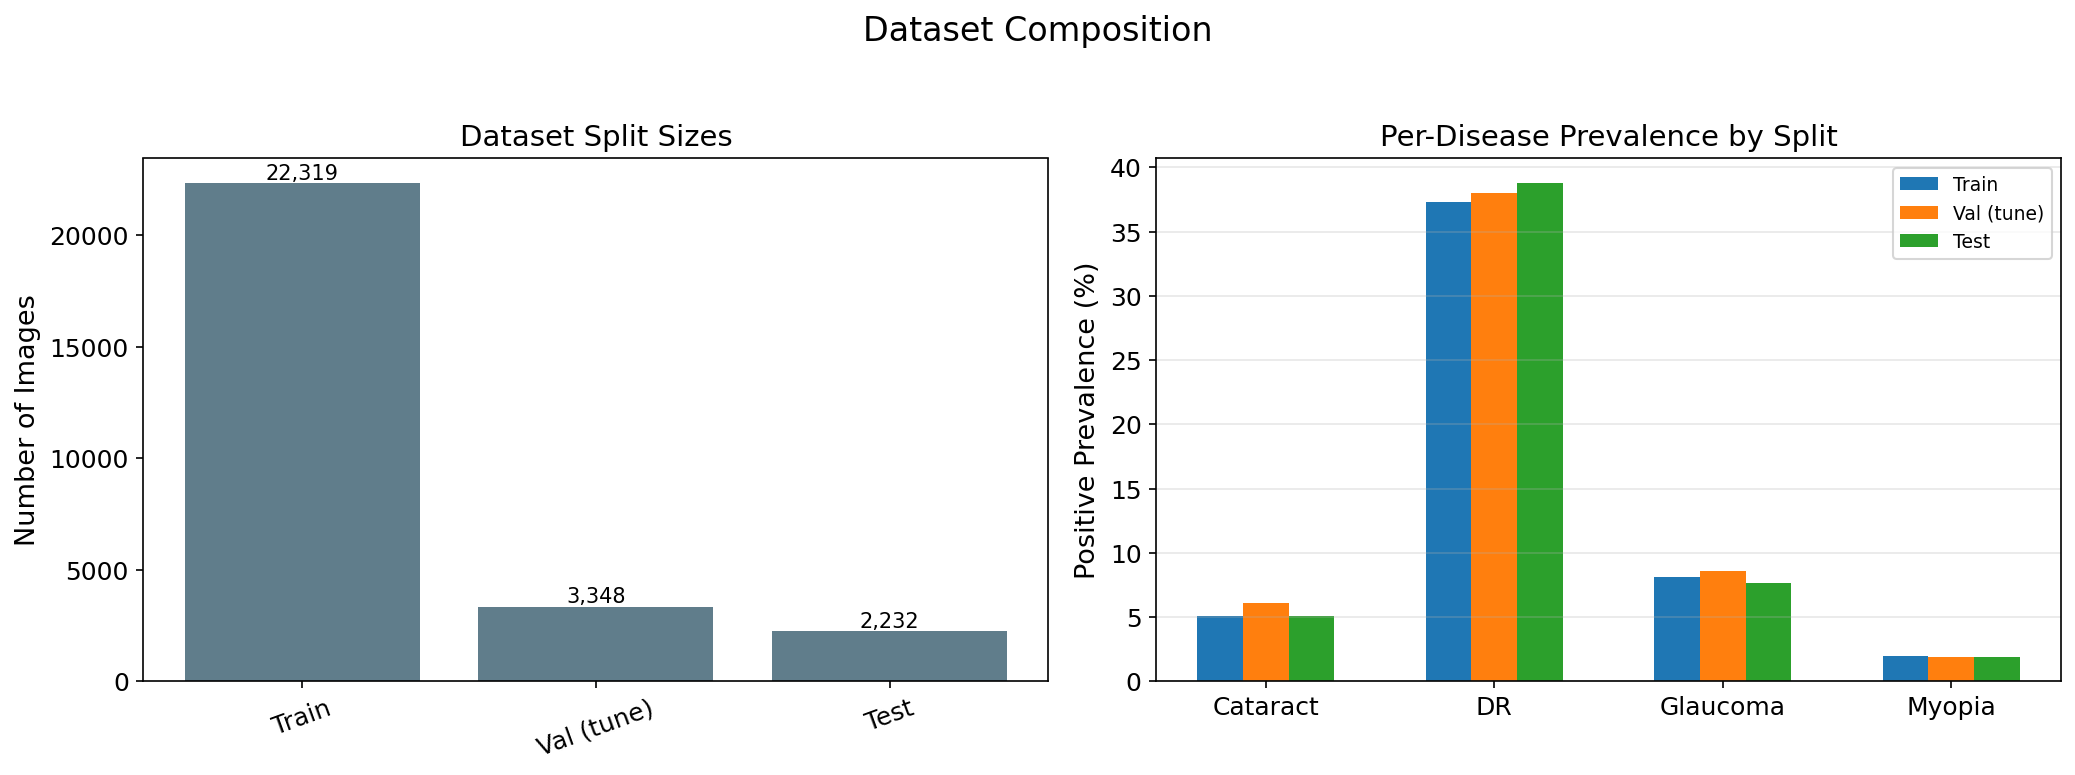

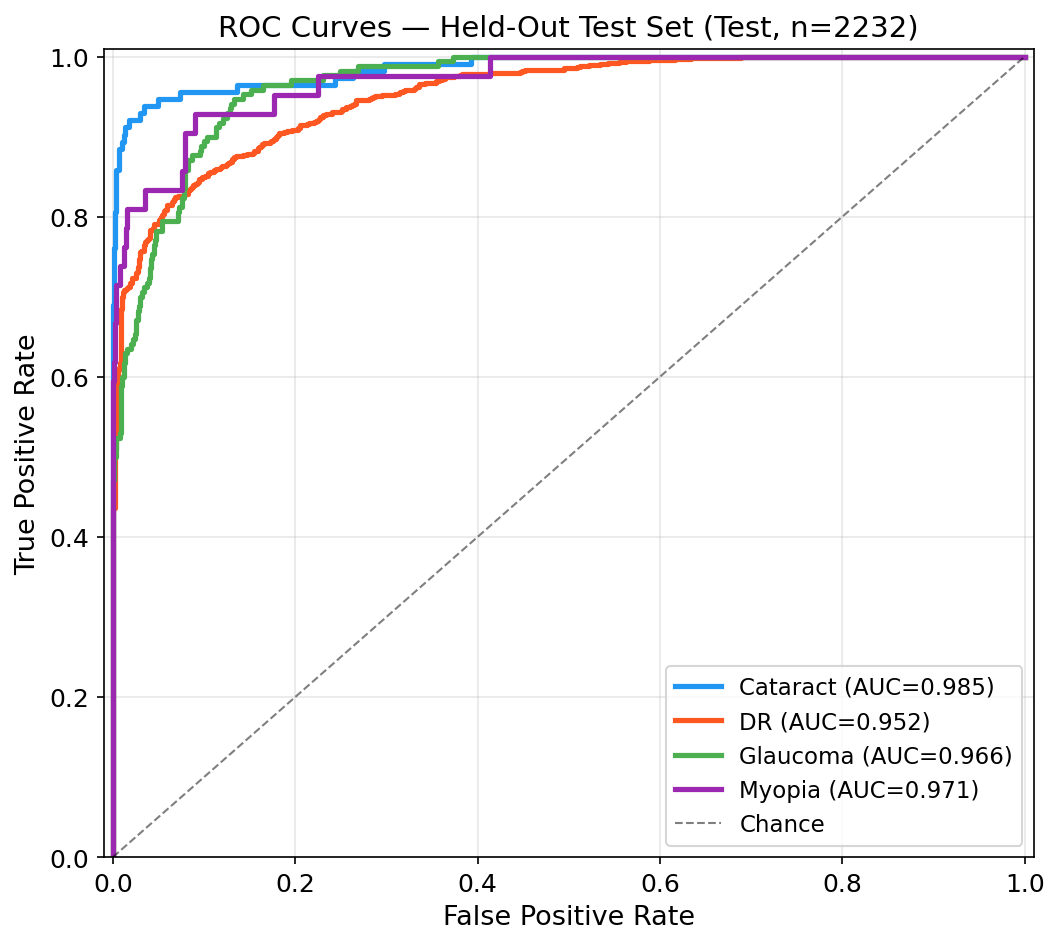

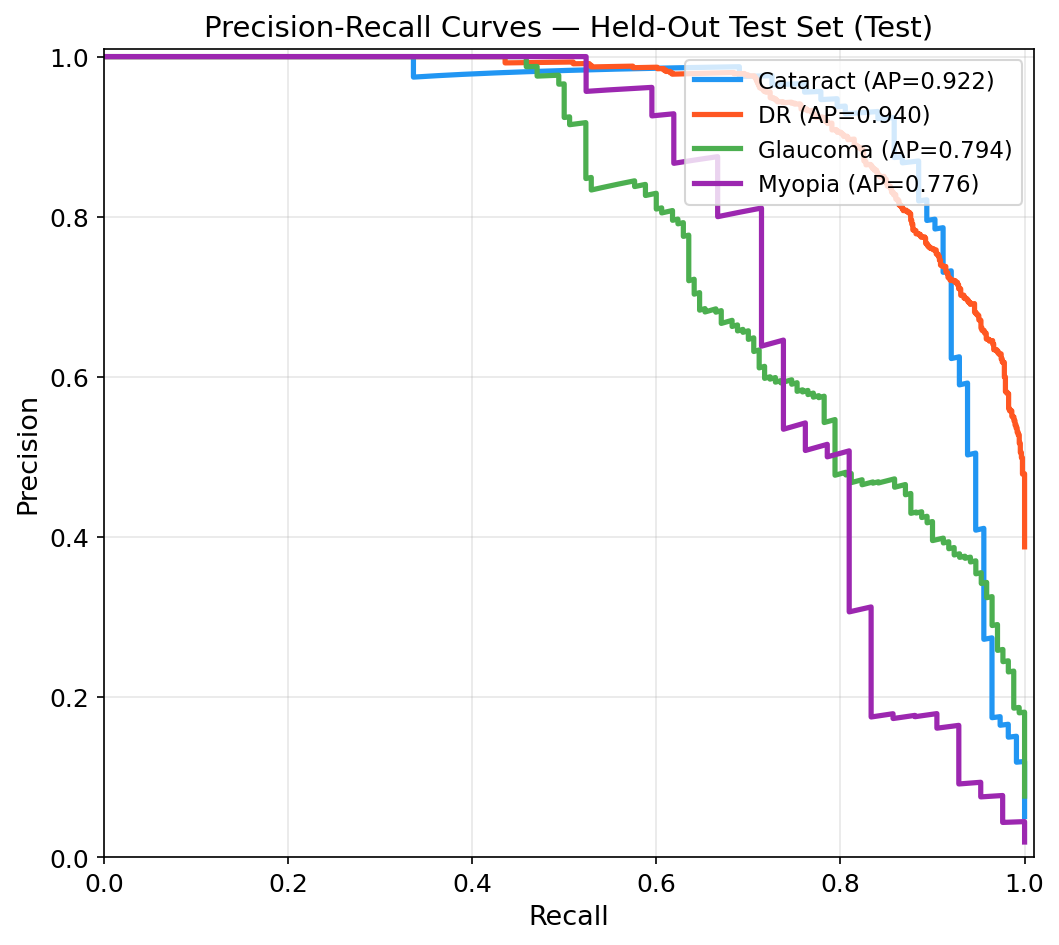

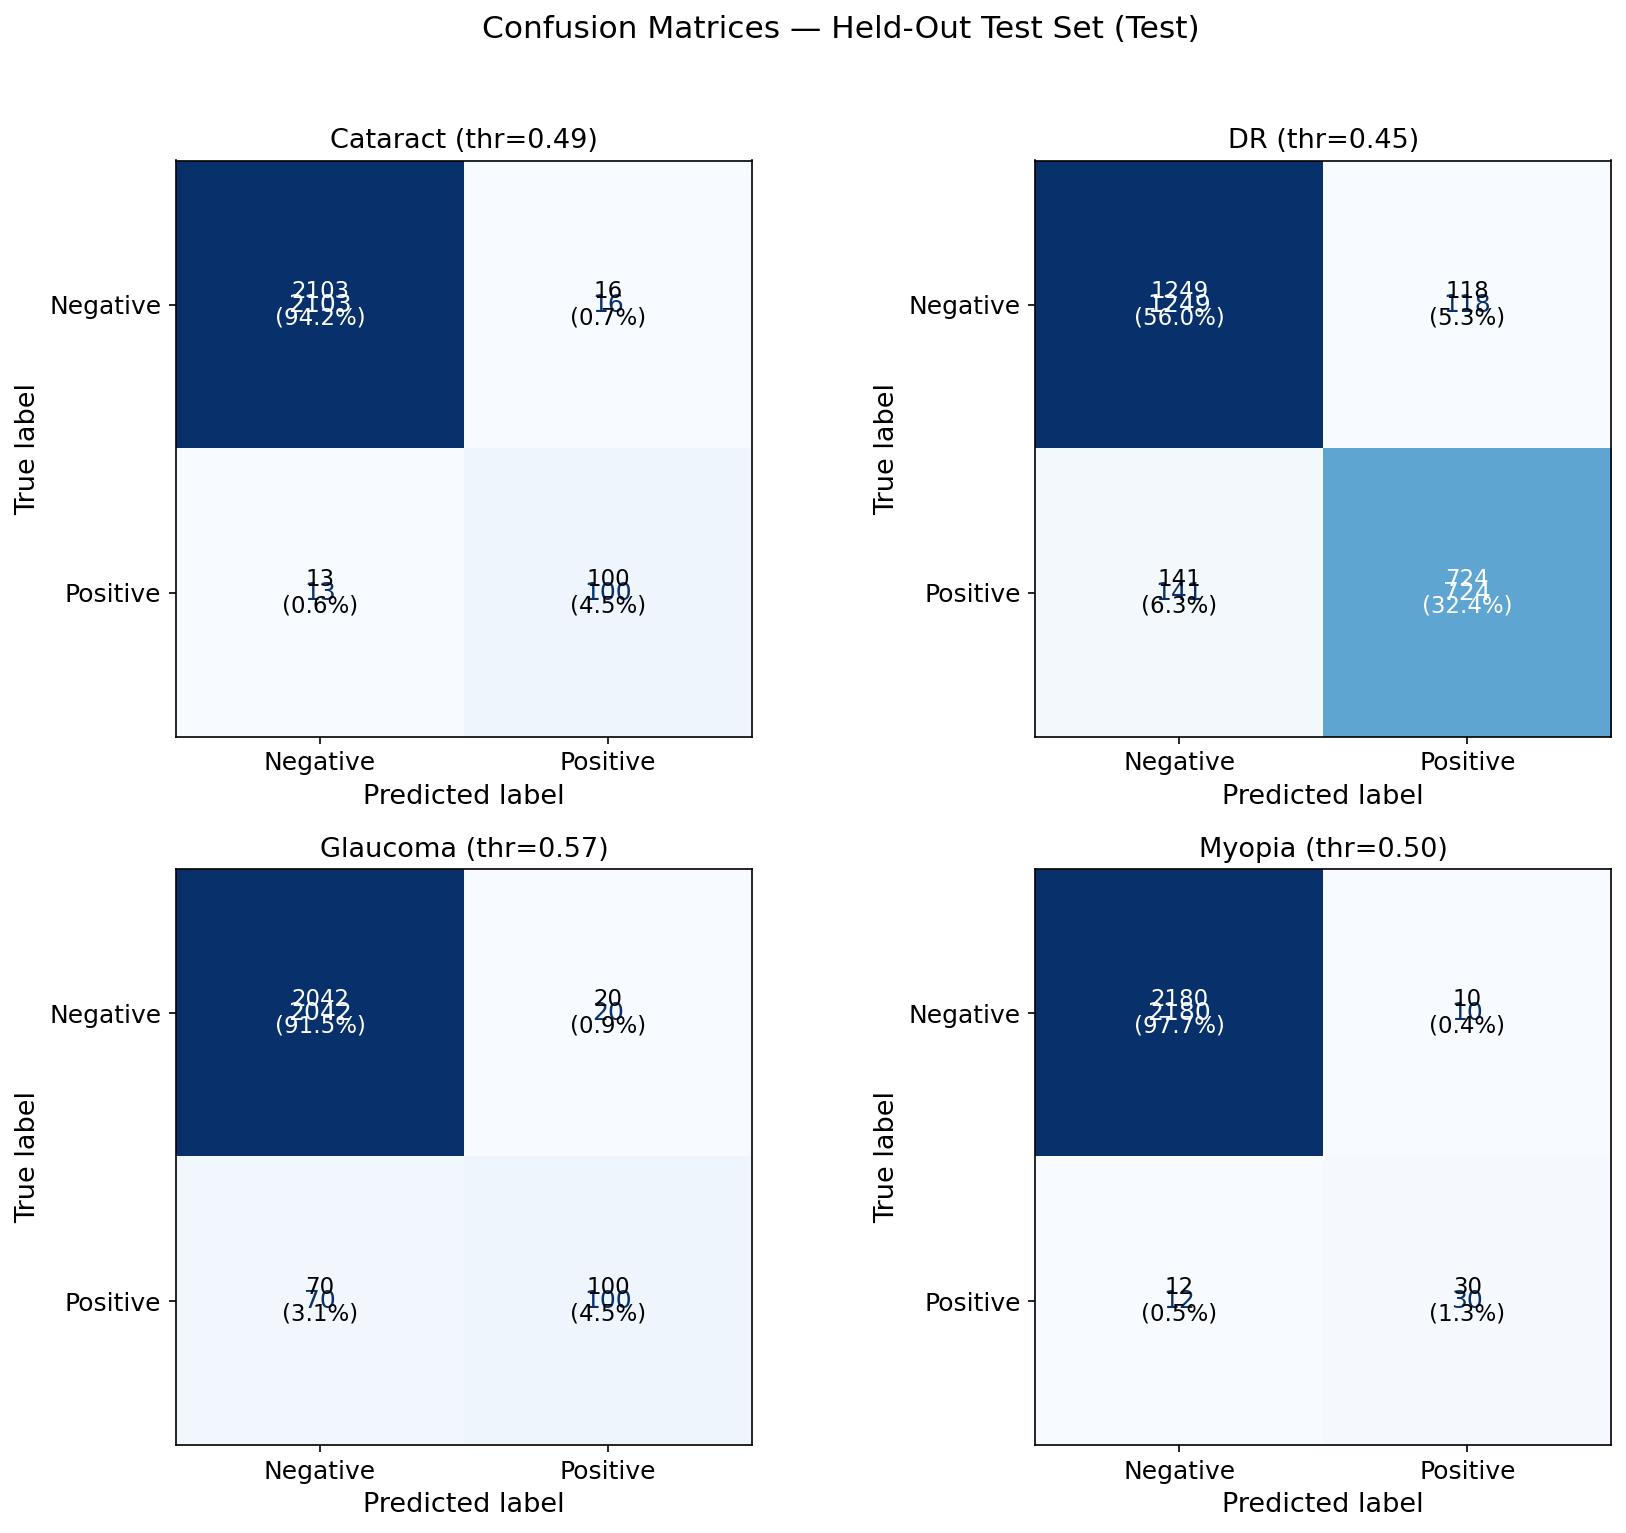

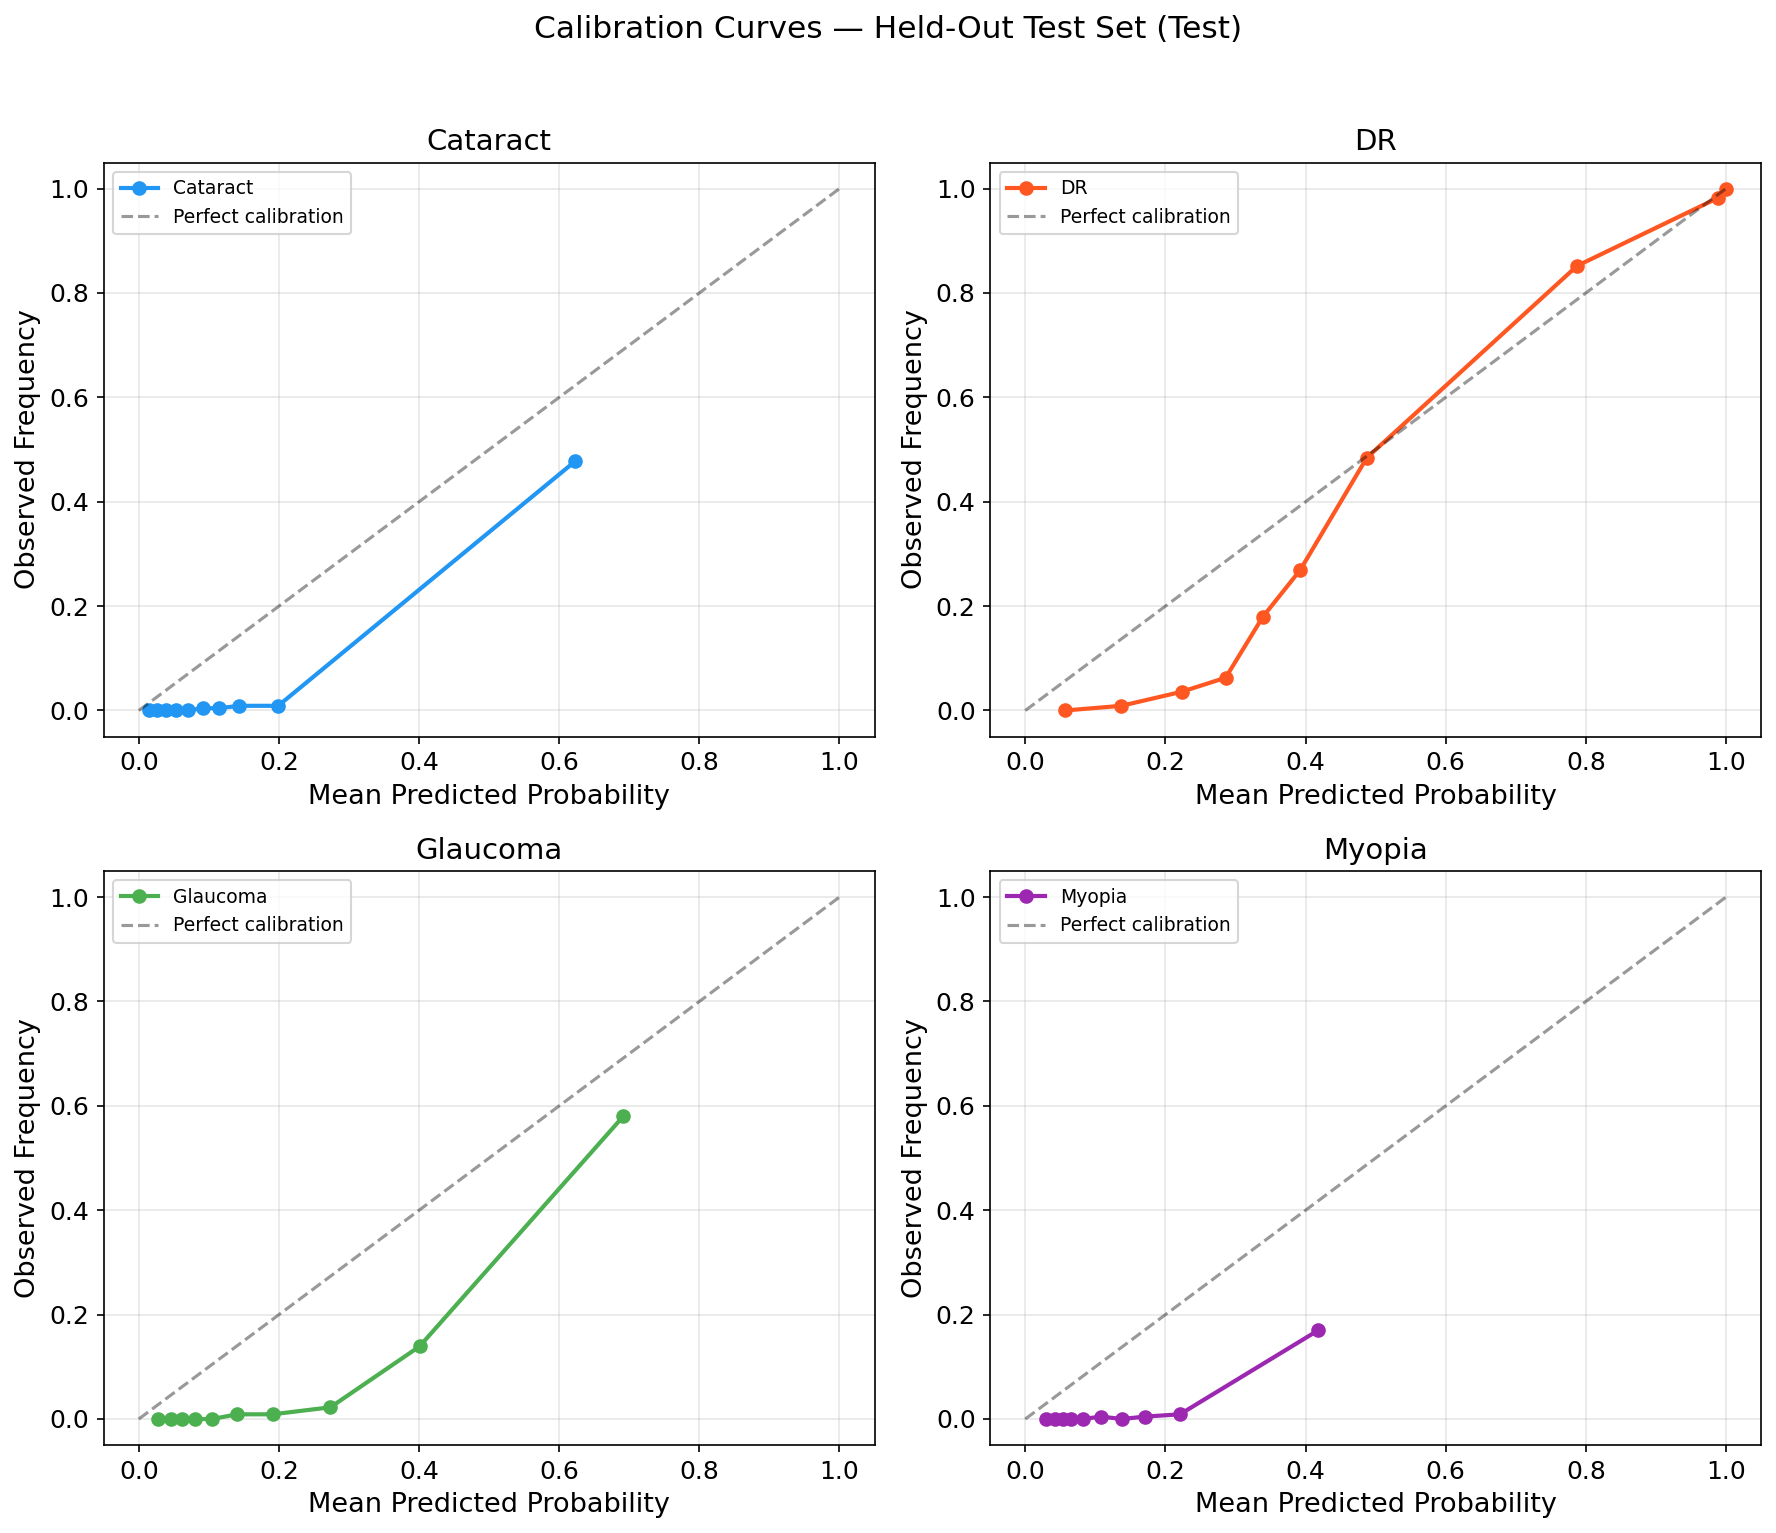

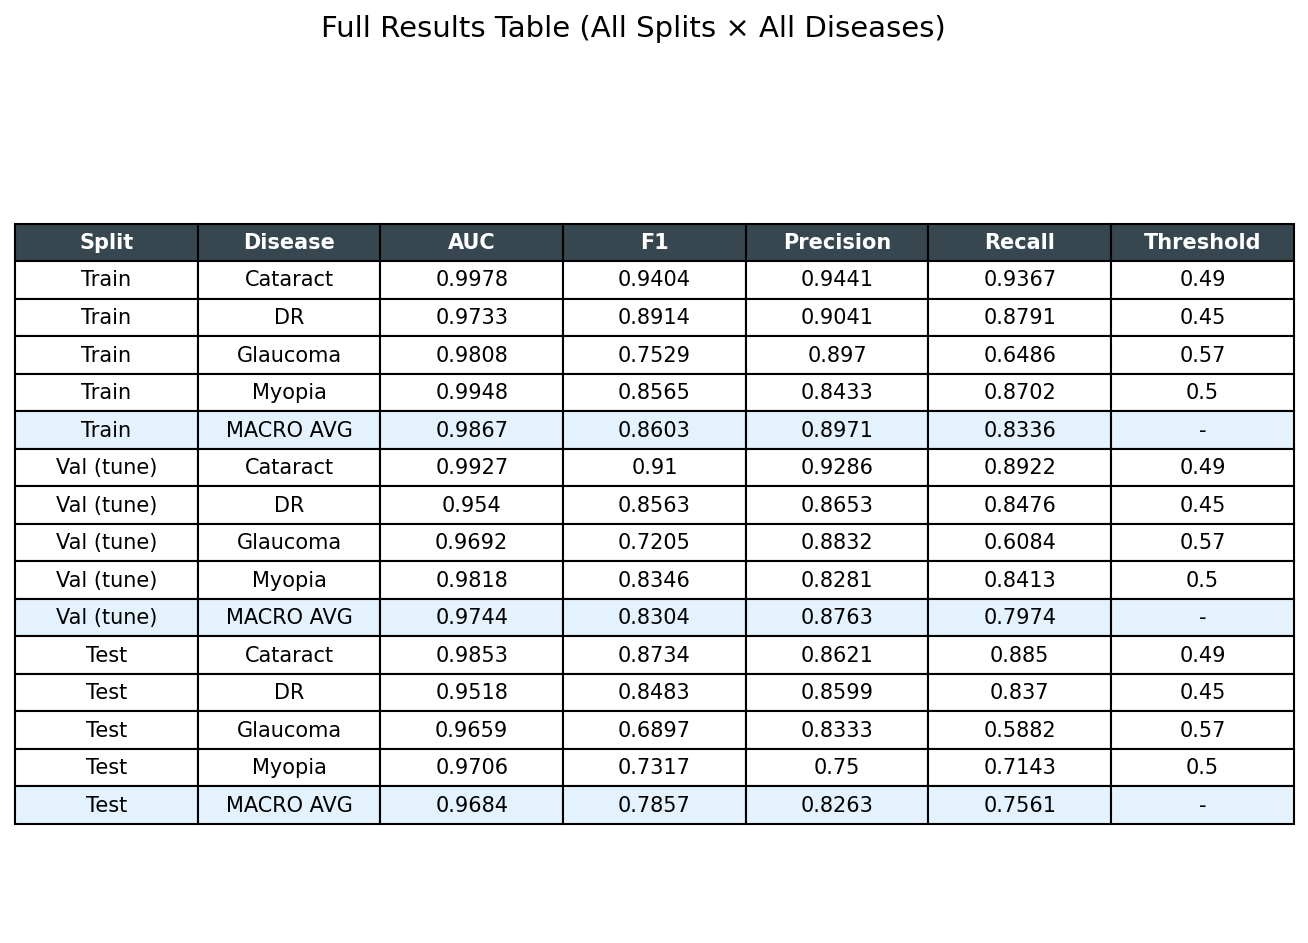

     Split   Disease    AUC     F1  Precision  Recall Threshold
     Train  Cataract 0.9978 0.9404     0.9441  0.9367      0.49
     Train        DR 0.9733 0.8914     0.9041  0.8791      0.45
     Train  Glaucoma 0.9808 0.7529     0.8970  0.6486      0.57
     Train    Myopia 0.9948 0.8565     0.8433  0.8702       0.5
     Train MACRO AVG 0.9867 0.8603     0.8971  0.8336         -
Val (tune)  Cataract 0.9927 0.9100     0.9286  0.8922      0.49
Val (tune)        DR 0.9540 0.8563     0.8653  0.8476      0.45
Val (tune)  Glaucoma 0.9692 0.7205     0.8832  0.6084      0.57
Val (tune)    Myopia 0.9818 0.8346     0.8281  0.8413       0.5
Val (tune) MACRO AVG 0.9744 0.8304     0.8763  0.7974         -
      Test  Cataract 0.9853 0.8734     0.8621  0.8850      0.49
      Test        DR 0.9518 0.8483     0.8599  0.8370      0.45
      Test  Glaucoma 0.9659 0.6897     0.8333  0.5882      0.57
      Test    Myopia 0.9706 0.7317     0.7500  0.7143       0.5
      Test MACRO AVG 0.9684 0.7857     0

In [19]:
import time
from sklearn.metrics import (
    roc_curve, auc as sk_auc, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

REPORT_DIR = f"{RUN_DIR}/report_assets"
os.makedirs(REPORT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 13,
    'legend.fontsize': 11, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1,
})
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

# Load best checkpoint once, reuse for every figure below
best_ckpt = torch.load(f"{RUN_DIR}/best_model.pth", map_location=device, weights_only=False)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()
final_thresholds = best_ckpt.get('optimal_thresholds', {d: 0.5 for d in DISEASE_NAMES})

# Gather logits/labels for every split we care about in the report.
# Val tune is included for completeness but TEST is the number that belongs in a paper.
report_splits = {
    "Train":            (train_df,  DataLoader(UnifiedDataset(train_df, img_root, DISEASE_NAMES, IMG_SIZE, is_train=False),
                                                  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)),
    "Val (tune)":        (val_tune_df, val_tune_loader),
    "Test":              (test_df, test_loader),
}
if test_extended_csv.exists():
    test_extended_df = pd.read_csv(test_extended_csv)
    test_extended_dataset = UnifiedDataset(test_extended_df, img_root, DISEASE_NAMES, IMG_SIZE, is_train=False)
    test_extended_loader = DataLoader(test_extended_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                       num_workers=NUM_WORKERS, pin_memory=True)
    report_splits["Test (extended)"] = (test_extended_df, test_extended_loader)

split_logits, split_labels, split_probs = {}, {}, {}
for name, (df_, loader_) in report_splits.items():
    print(f"Running inference on: {name} ({len(df_)} images)...")
    logits, labels = evaluate(model, loader_)
    split_logits[name] = logits
    split_labels[name] = labels
    split_probs[name] = 1 / (1 + np.exp(-logits))

TEST_SPLIT_NAME = "Test (extended)" if "Test (extended)" in report_splits else "Test"

# ─────────────────────────────────────────────────────────────
# 1. Dataset composition — sample counts + per-disease prevalence
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

split_sizes = {name: len(df_) for name, (df_, _) in report_splits.items()}
axes[0].bar(split_sizes.keys(), split_sizes.values(), color='#607D8B')
axes[0].set_title('Dataset Split Sizes')
axes[0].set_ylabel('Number of Images')
for i, (k, v) in enumerate(split_sizes.items()):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)

x = np.arange(len(DISEASE_NAMES))
width = 0.2
for i, (name, (df_, _)) in enumerate(report_splits.items()):
    prevalence = df_[DISEASE_NAMES].mean().values * 100
    axes[1].bar(x + i * width, prevalence, width, label=name)
axes[1].set_xticks(x + width * (len(report_splits) - 1) / 2)
axes[1].set_xticklabels(DISEASE_NAMES)
axes[1].set_ylabel('Positive Prevalence (%)')
axes[1].set_title('Per-Disease Prevalence by Split')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle('Dataset Composition', fontsize=16, y=1.03)
fig.tight_layout()
fig.savefig(f"{REPORT_DIR}/01_dataset_composition.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# 2. Held-out TEST set: ROC curves
# ─────────────────────────────────────────────────────────────
y_true_test = split_labels[TEST_SPLIT_NAME]
y_prob_test = split_probs[TEST_SPLIT_NAME]

fig, ax = plt.subplots(figsize=(8, 7))
for i, d in enumerate(DISEASE_NAMES):
    yt, yp = y_true_test[:, i], y_prob_test[:, i]
    if len(np.unique(yt)) > 1:
        fpr, tpr, _ = roc_curve(yt, yp)
        roc_auc = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2.5, color=colors[i], label=f'{d} (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — Held-Out Test Set ({TEST_SPLIT_NAME}, n={len(y_true_test)})')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.01, 1.01); ax.set_ylim(0.0, 1.01)
fig.savefig(f"{REPORT_DIR}/02_test_roc_curves.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# 3. Held-out TEST set: Precision-Recall curves
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
for i, d in enumerate(DISEASE_NAMES):
    yt, yp = y_true_test[:, i], y_prob_test[:, i]
    if len(np.unique(yt)) > 1:
        prec, rec, _ = precision_recall_curve(yt, yp)
        ap = average_precision_score(yt, yp)
        ax.plot(rec, prec, linewidth=2.5, color=colors[i], label=f'{d} (AP={ap:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curves — Held-Out Test Set ({TEST_SPLIT_NAME})')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.0, 1.01); ax.set_ylim(0.0, 1.01)
fig.savefig(f"{REPORT_DIR}/03_test_pr_curves.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# 4. Held-out TEST set: Confusion matrices (optimal thresholds)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, d in enumerate(DISEASE_NAMES):
    ax = axes[i]
    yt = y_true_test[:, i].astype(int)
    yp = y_prob_test[:, i]
    thr = final_thresholds.get(d, 0.5)
    pred = (yp >= thr).astype(int)
    cm = confusion_matrix(yt, pred, labels=[0, 1])
    cm_pct = cm / cm.sum() * 100
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{cm[r,c]}\n({cm_pct[r,c]:.1f}%)', ha='center', va='center',
                     fontsize=11, color='white' if cm[r, c] > cm.max() * 0.5 else 'black')
    ax.set_title(f'{d} (thr={thr:.2f})', fontsize=13)
fig.suptitle(f'Confusion Matrices — Held-Out Test Set ({TEST_SPLIT_NAME})', fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(f"{REPORT_DIR}/04_test_confusion_matrices.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# 5. Calibration (reliability) curves — how trustworthy are the probabilities?
#    Important for a clinical screening tool: a 0.8 "probability" should mean
#    roughly 80% of such cases really are positive.
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, d in enumerate(DISEASE_NAMES):
    ax = axes[i]
    yt, yp = y_true_test[:, i], y_prob_test[:, i]
    if len(np.unique(yt)) > 1:
        frac_pos, mean_pred = calibration_curve(yt, yp, n_bins=10, strategy='quantile')
        ax.plot(mean_pred, frac_pos, 'o-', color=colors[i], linewidth=2, label=d)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Observed Frequency')
    ax.set_title(d)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle(f'Calibration Curves — Held-Out Test Set ({TEST_SPLIT_NAME})', fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(f"{REPORT_DIR}/05_calibration_curves.png")
plt.show()

# ─────────────────────────────────────────────────────────────
# 6. Master results table — every split, every disease, every metric
#    Saved as CSV (for LaTeX/Excel import) and as a rendered PNG table.
# ─────────────────────────────────────────────────────────────
rows = []
for name in report_splits.keys():
    m, _ = compute_metrics(split_logits[name], split_labels[name], final_thresholds)
    for d in DISEASE_NAMES:
        rows.append({
            'Split': name, 'Disease': d,
            'AUC': round(m[d]['auc'], 4), 'F1': round(m[d]['f1'], 4),
            'Precision': round(m[d]['precision'], 4), 'Recall': round(m[d]['recall'], 4),
            'Threshold': round(final_thresholds.get(d, 0.5), 3),
        })
    rows.append({'Split': name, 'Disease': 'MACRO AVG',
                 'AUC': round(np.mean([m[d]['auc'] for d in DISEASE_NAMES]), 4),
                 'F1': round(m['macro_f1'], 4),
                 'Precision': round(np.mean([m[d]['precision'] for d in DISEASE_NAMES]), 4),
                 'Recall': round(np.mean([m[d]['recall'] for d in DISEASE_NAMES]), 4),
                 'Threshold': '-'})

results_table = pd.DataFrame(rows)
results_table.to_csv(f"{REPORT_DIR}/results_table.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 0.4 * len(results_table) + 1))
ax.axis('off')
tbl = ax.table(cellText=results_table.values, colLabels=results_table.columns,
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
for j in range(len(results_table.columns)):
    tbl[0, j].set_facecolor('#37474F')
    tbl[0, j].set_text_props(color='white', weight='bold')
for i, row in enumerate(results_table.itertuples(), start=1):
    if row.Disease == 'MACRO AVG':
        for j in range(len(results_table.columns)):
            tbl[i, j].set_facecolor('#E3F2FD')
fig.suptitle('Full Results Table (All Splits × All Diseases)', fontsize=14, y=0.98)
fig.savefig(f"{REPORT_DIR}/06_results_table.png", bbox_inches='tight')
plt.show()
print(results_table.to_string(index=False))

# ─────────────────────────────────────────────────────────────
# 7. Model efficiency summary — params, size, inference latency
#    Relevant since GLAAM-4X is positioned as a lightweight screening model.
# ─────────────────────────────────────────────────────────────
raw_model = model._orig_mod if hasattr(model, '_orig_mod') else model  # unwrap torch.compile if used
total_params = sum(p.numel() for p in raw_model.parameters())
trainable_params = sum(p.numel() for p in raw_model.parameters() if p.requires_grad)

safet_path = f"{RUN_DIR}/best_model.safetensors"
model_size_mb = os.path.getsize(safet_path) / (1024 ** 2) if os.path.exists(safet_path) else None

# Latency benchmark: single-image forward pass, GPU synced if available
raw_model.eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    for _ in range(10):  # warmup
        _ = raw_model(dummy)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    timings = []
    for _ in range(50):
        t0 = time.time()
        _ = raw_model(dummy)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        timings.append((time.time() - t0) * 1000)
mean_latency_ms = float(np.mean(timings))
p95_latency_ms = float(np.percentile(timings, 95))

efficiency_summary = {
    "total_parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "model_size_mb_safetensors": round(model_size_mb, 2) if model_size_mb else None,
    "inference_device": str(device),
    "mean_latency_ms_bs1": round(mean_latency_ms, 2),
    "p95_latency_ms_bs1": round(p95_latency_ms, 2),
    "input_resolution": IMG_SIZE,
}
with open(f"{REPORT_DIR}/model_efficiency_summary.json", 'w') as f:
    json.dump(efficiency_summary, f, indent=2)

print(f"\n{'='*60}")
print("MODEL EFFICIENCY SUMMARY")
print(f"{'='*60}")
for k, v in efficiency_summary.items():
    print(f"  {k:28s}: {v}")
print(f"{'='*60}")

print(f"\n✅ All report assets saved to: {REPORT_DIR}/")
for f in sorted(os.listdir(REPORT_DIR)):
    print(f"  {f}")


# Section 14: Export Inference-Ready Artifacts

This section packages the trained model into a portable inference bundle so it can be deployed without re-running training. The bundle includes clean model weights (`model_weights.pth` and `best_model.safetensors`), per-disease optimal thresholds (`thresholds.json`), training metadata (`model_info.json`), a standalone inference script (`predict.py`), and usage instructions (`README.md`). A zip archive is also created for one-click download. The inference script can be run from the command line (`python predict.py --weights model_weights.pth --image fundus.jpg --thresholds thresholds.json`) or imported as a Python API, making the model usable in clinics, web services, mobile pipelines, or other cloud instances.

In [21]:
import zipfile

# ═══════════════════════════════════════════════════════════════
# Export Inference-Ready Artifacts to Drive
# ═══════════════════════════════════════════════════════════════

INFERENCE_DIR = f"{DRIVE_BASE}/inference_package_{MODEL_NAME}"
os.makedirs(INFERENCE_DIR, exist_ok=True)

print(f"Exporting inference artifacts to: {INFERENCE_DIR}/")

# 1. Save clean model weights (state_dict only, no optimizer)
clean_weights_path = f"{INFERENCE_DIR}/model_weights.pth"
torch.save(model.state_dict(), clean_weights_path)
print(f"✅ Clean weights saved: {clean_weights_path}")

# 2. Save optimal thresholds
thresholds_path = f"{INFERENCE_DIR}/thresholds.json"
with open(thresholds_path, 'w') as f:
    json.dump(final_results['optimal_thresholds'], f, indent=2)
print(f"✅ Thresholds saved: {thresholds_path}")

# 3. Save model metadata
model_info = {
    "model_name": MODEL_NAME,
    "architecture": "GLAAM-4X",
    "backbone": "MobileNetV2",
    "num_classes": 4,
    "disease_names": DISEASE_NAMES,
    "img_size": IMG_SIZE,
    "dropout_rate": DROPOUT_RATE,
    "best_epoch": final_results.get('best_epoch', 0),
    "best_val_tune_f1": final_results.get('best_val_tune_f1', 0.0),
    "test_results": {
        k: {
            "num_images": v['num_images'],
            "macro_f1": v['metrics']['macro_f1']
        }
        for k, v in final_results.get('test_results', {}).items()
    },
    "training_config": {
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "epochs_trained": best_epoch,
        "warmup_epochs": WARMUP_EPOCHS,
        "asl_gamma_neg": ASL_GAMMA_NEG,
        "asl_gamma_pos": ASL_GAMMA_POS,
        "asl_clip": ASL_CLIP,
    }
}
model_info_path = f"{INFERENCE_DIR}/model_info.json"
with open(model_info_path, 'w') as f:
    json.dump(model_info, f, indent=2)
print(f"✅ Model info saved: {model_info_path}")

# 4. Create standalone predict.py script
predict_script = '''#!/usr/bin/env python3
"""
Standalone inference script for GLAAM-4X v4
Load model, run prediction on single image or folder.
"""
import torch
import torch.nn as nn
import cv2
import numpy as np
import json
from pathlib import Path

DISEASE_NAMES = ['Cataract', 'DR', 'Glaucoma', 'Myopia']

class GLAAM4XClassifier(nn.Module):
    REORDER_IDX = [2, 0, 1, 3]
    def __init__(self, dropout_rate=0.3, pretrained=False):
        super().__init__()
        # NOTE: Update this import path if your project structure differs
        from models.glaam_4x import GLAAM_4X
        self.backbone = GLAAM_4X(pretrained=pretrained, dropout_rate=dropout_rate)
    def forward(self, x):
        out = self.backbone(x)
        logits = out['logits']
        return logits[:, self.REORDER_IDX]

def load_model(weights_path, device='cuda'):
    model = GLAAM4XClassifier(dropout_rate=0.3, pretrained=False)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def preprocess_image(img_path, img_size=384):
    img = cv2.imread(str(img_path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img - mean) / std
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)
    return img

def predict(model, img_path, thresholds=None, device='cuda', img_size=384):
    if thresholds is None:
        thresholds = {d: 0.5 for d in DISEASE_NAMES}
    img = preprocess_image(img_path, img_size).to(device)
    with torch.no_grad():
        logits = model(img)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    results = {}
    for i, disease in enumerate(DISEASE_NAMES):
        prob = float(probs[i])
        pred = int(prob >= thresholds.get(disease, 0.5))
        results[disease] = {"probability": round(prob, 4), "prediction": pred}
    return results

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--weights", required=True, help="Path to model_weights.pth")
    parser.add_argument("--image", required=True, help="Path to fundus image")
    parser.add_argument("--thresholds", default="thresholds.json", help="Path to thresholds.json")
    parser.add_argument("--device", default="cuda", help="cuda or cpu")
    parser.add_argument("--img_size", type=int, default=384)
    args = parser.parse_args()

    device = torch.device(args.device if torch.cuda.is_available() else "cpu")
    model = load_model(args.weights, device)

    thresholds = {d: 0.5 for d in DISEASE_NAMES}
    if Path(args.thresholds).exists():
        with open(args.thresholds) as f:
            thresholds = json.load(f)

    results = predict(model, args.image, thresholds, device, args.img_size)
    print(json.dumps(results, indent=2))
'''

predict_path = f"{INFERENCE_DIR}/predict.py"
with open(predict_path, 'w') as f:
    f.write(predict_script)
print(f"✅ Inference script saved: {predict_path}")

# 5. Create README for the package
readme = f'''# GLAAM-4X v4 Inference Package

## Contents
- `model_weights.pth` — Clean model state dict (~14MB)
- `best_model.safetensors` — SafeTensors format (same weights)
- `thresholds.json` — Per-disease optimal thresholds
- `model_info.json` — Training metadata and config
- `predict.py` — Standalone inference script

## Quick Start

### Single Image Prediction
```bash
python predict.py \\
    --weights model_weights.pth \\
    --image path/to/fundus.jpg \\
    --thresholds thresholds.json
```

### Load in Python
```python
import torch
from predict import load_model, predict

model = load_model("model_weights.pth", device="cuda")
results = predict(model, "fundus.jpg", thresholds={"Cataract": 0.45, ...})
print(results)
# {{"Cataract": {{"probability": 0.9234, "prediction": 1}}, ...}}
```

## Model Info
- Architecture: GLAAM-4X (MobileNetV2 + 4 attention heads)
- Input size: {IMG_SIZE}x{IMG_SIZE}
- Diseases: {', '.join(DISEASE_NAMES)}
- Best Val F1: {final_results.get('best_val_tune_f1', 0):.4f}

## Thresholds
'''
for d in DISEASE_NAMES:
    thr = final_results.get('optimal_thresholds', {}).get(d, 0.5)
    readme += f"- {d}: {thr:.2f}\n"

readme_path = f"{INFERENCE_DIR}/README.md"
with open(readme_path, 'w') as f:
    f.write(readme)
print(f"✅ README saved: {readme_path}")

# 6. Copy best safetensors to inference dir
import shutil
src_safetensors = f"{RUN_DIR}/best_model.safetensors"
dst_safetensors = f"{INFERENCE_DIR}/best_model.safetensors"
if os.path.exists(src_safetensors):
    shutil.copy(src_safetensors, dst_safetensors)
    print(f"✅ SafeTensors copied to inference package")
else:
    print(f"⚠️  best_model.safetensors not found; skipping copy")

# 7. Create zip archive for easy download
zip_path = f"{DRIVE_BASE}/{MODEL_NAME}_inference_package.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in ['model_weights.pth', 'best_model.safetensors', 'thresholds.json',
              'model_info.json', 'predict.py', 'README.md']:
        fp = f"{INFERENCE_DIR}/{f}"
        if os.path.exists(fp):
            zf.write(fp, f)
        elif f == 'best_model.safetensors':
            print(f"⚠️  {f} not present; continuing zip without it")
print(f"✅ Zip package created: {zip_path}")

print(f"\n{'='*60}")
print(f"📦 INFERENCE PACKAGE READY")
print(f"{'='*60}")
print(f"Location: {INFERENCE_DIR}/")
print(f"Zip:      {zip_path}")
print(f"\nFiles:")
for f in sorted(os.listdir(INFERENCE_DIR)):
    size = os.path.getsize(f"{INFERENCE_DIR}/{f}") / (1024*1024)
    print(f"  {f:30s} ({size:.1f} MB)")
print(f"{'='*60}")


Exporting inference artifacts to: /content/drive/MyDrive/Backup/dataset/cataract_detection/inference_package_glaam4x_unified_v4_asl_384/
✅ Clean weights saved: /content/drive/MyDrive/Backup/dataset/cataract_detection/inference_package_glaam4x_unified_v4_asl_384/model_weights.pth
✅ Thresholds saved: /content/drive/MyDrive/Backup/dataset/cataract_detection/inference_package_glaam4x_unified_v4_asl_384/thresholds.json
✅ Model info saved: /content/drive/MyDrive/Backup/dataset/cataract_detection/inference_package_glaam4x_unified_v4_asl_384/model_info.json
✅ Inference script saved: /content/drive/MyDrive/Backup/dataset/cataract_detection/inference_package_glaam4x_unified_v4_asl_384/predict.py


ValueError: Invalid format specifier ' 0.45, ...' for object of type 'str'